Est-ce qu’il y a un effet de lag entre SPY et AAPL ? (Y a-t-il des répercutions des mouvements du prix du SP500 sur le prix d'AAPLe quelques centièmes / dixième de seconde plus tard ? Ou sur le volume ?)


Pour y répondre nous étudierons les variations de prix, la corrélation entre le volume et le spread, la corrélation entre le volume et le prix, sur différentes rolling window, avec et sans lag.



In [54]:
import polars as pl
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf

In [55]:
pl.Config.set_tbl_cols(200)               
pl.Config.set_tbl_rows(50)                

polars.config.Config

In [56]:
df = (pl.scan_parquet("../data/AAPL.OQ/AAPL.OQ/*.parquet").collect())
print(df)

shape: (10_876_798, 5)
┌──────────────┬─────────────┬──────────────┬──────────────────┬───────────────┐
│ V1           ┆ trade-price ┆ trade-volume ┆ trade-stringflag ┆ trade-rawflag │
│ ---          ┆ ---         ┆ ---          ┆ ---              ┆ ---           │
│ f64          ┆ f64         ┆ f64          ┆ f64              ┆ f64           │
╞══════════════╪═════════════╪══════════════╪══════════════════╪═══════════════╡
│ 39815.526917 ┆ 85.95       ┆ 175.0        ┆ null             ┆ null          │
│ 39815.539092 ┆ 86.15       ┆ 200.0        ┆ null             ┆ null          │
│ 39815.541686 ┆ 86.15       ┆ 100.0        ┆ null             ┆ null          │
│ 39815.542877 ┆ 86.0        ┆ 174.0        ┆ null             ┆ null          │
│ 39815.543002 ┆ 86.0        ┆ 100.0        ┆ null             ┆ null          │
│ 39815.543004 ┆ 86.0        ┆ 100.0        ┆ null             ┆ null          │
│ 39815.543004 ┆ 86.0        ┆ 100.0        ┆ null             ┆ null          │
│ 398

In [57]:
origin = dt.datetime(1899, 12, 30)

df = (df.drop(["trade-stringflag", "trade-rawflag"]).drop_nulls(subset=["V1", "trade-price", "trade-volume"]).rename({"V1": "excel_time","trade-price": "price","trade-volume": "volume",}).with_columns(pl.col("excel_time").map_elements(lambda x: origin + dt.timedelta(days=float(x))).alias("datetime")).drop("excel_time"))

df = df.with_columns(pl.col("datetime").dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York") )

df = (df.filter(pl.col("datetime").dt.time().is_between(pl.time(9, 30), pl.time(16, 0)) ).sort("datetime").select(["datetime", "price", "volume"]))

print(df.head())
print(df.columns)

shape: (5, 3)
┌────────────────────────────────┬───────┬────────┐
│ datetime                       ┆ price ┆ volume │
│ ---                            ┆ ---   ┆ ---    │
│ datetime[μs, America/New_York] ┆ f64   ┆ f64    │
╞════════════════════════════════╪═══════╪════════╡
│ 2009-01-02 09:30:00.311 EST    ┆ 85.62 ┆ 100.0  │
│ 2009-01-02 09:30:00.483 EST    ┆ 85.62 ┆ 200.0  │
│ 2009-01-02 09:30:00.483 EST    ┆ 85.62 ┆ 100.0  │
│ 2009-01-02 09:30:00.654 EST    ┆ 85.6  ┆ 300.0  │
│ 2009-01-02 09:30:00.698 EST    ┆ 85.6  ┆ 200.0  │
└────────────────────────────────┴───────┴────────┘
['datetime', 'price', 'volume']


In [58]:
df = df.select(["datetime", "price", "volume"])

In [59]:
df = (df.group_by("datetime").agg([pl.col("price").mean().alias("price"),pl.col("volume").mean().alias("volume"),]).sort("datetime"))

## deuxieme data frame


In [60]:
df1 = (pl.scan_parquet("../data/SPY.P/SPY.P/*.parquet").collect())
print(df1)

shape: (34_350_981, 5)
┌──────────────┬─────────────┬──────────────┬───────────────────────────┬──────────────────────────┐
│ xltime       ┆ trade-price ┆ trade-volume ┆ trade-stringflag          ┆ trade-rawflag            │
│ ---          ┆ ---         ┆ ---          ┆ ---                       ┆ ---                      │
│ f64          ┆ f64         ┆ i32          ┆ str                       ┆ str                      │
╞══════════════╪═════════════╪══════════════╪═══════════════════════════╪══════════════════════════╡
│ 39815.410054 ┆ 89.99       ┆ 100          ┆ marketclosed|volumeupdate ┆ [IRG            ]131     │
│              ┆             ┆              ┆                           ┆ …                        │
│ 39815.4416   ┆ 90.01       ┆ 200          ┆ marketclosed|volumeupdate ┆ [IRG            ]131     │
│              ┆             ┆              ┆                           ┆ …                        │
│ 39815.447097 ┆ 90.14       ┆ 100          ┆ marketclosed|volumeupd

In [61]:
origin = dt.datetime(1899, 12, 30)

df1 = (
    df1
    .drop(["trade-stringflag", "trade-rawflag"])
    .drop_nulls(subset=["xltime", "trade-price", "trade-volume"])
    .rename({
        "xltime": "excel_time",
        "trade-price": "price",
        "trade-volume": "volume",
    })
    .with_columns(
        pl.col("excel_time")
        .map_elements(lambda x: origin + dt.timedelta(days=float(x)))
        .alias("datetime")
    )
    .drop("excel_time")
)


df1 = df1.with_columns(pl.col("datetime").dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York"))

df1 = (
    df1
    .filter(
        pl.col("datetime")
        .dt.time()
        .is_between(pl.time(9, 30), pl.time(16, 0))  
    )
    .sort("datetime")
    .select(["datetime", "price", "volume"])         
)

print(df1.head())
print(df1.columns)

shape: (5, 3)
┌────────────────────────────────┬───────┬────────┐
│ datetime                       ┆ price ┆ volume │
│ ---                            ┆ ---   ┆ ---    │
│ datetime[μs, America/New_York] ┆ f64   ┆ i32    │
╞════════════════════════════════╪═══════╪════════╡
│ 2009-01-02 09:30:00.109 EST    ┆ 90.45 ┆ 156    │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.45 ┆ 110    │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.44 ┆ 200    │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.44 ┆ 1000   │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.44 ┆ 800    │
└────────────────────────────────┴───────┴────────┘
['datetime', 'price', 'volume']


In [62]:
df1 = df1.select(["datetime", "price", "volume"])

In [63]:
df1 = (
    df1
    .group_by("datetime")
    .agg([
        pl.col("price").mean().alias("price"),
        pl.col("volume").mean().alias("volume"),
    ])
    .sort("datetime")
)

## mnt on a les data frame df et df1


In [64]:
def bucket_1min(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by_dynamic(
            "datetime",
            every="1m",    # bucket de 1 minute
            period="1m",
            closed="left",
            label="left",  # timestamp = début de la minute
        )
        .agg([
            pl.col("price").mean().alias("price"),
            pl.col("volume").sum().alias("volume"),
        ])
        .sort("datetime")
    )

In [65]:
df1_min = bucket_1min(df)
df2_min = bucket_1min(df1)

In [66]:
df1_min = df1_min.rename({"datetime": "datetime","price": "price_AAPL","volume": "volume_AAPL",})

In [67]:
df2_min = df2_min.rename({"datetime": "datetime","price": "price_SPY","volume": "volume_SPY",})

In [68]:
df1_min.head()

datetime,price_AAPL,volume_AAPL
"datetime[μs, America/New_York]",f64,f64
2009-01-02 09:30:00 EST,85.747912,79660.9
2009-01-02 09:31:00 EST,85.5945,14969.909524
2009-01-02 09:32:00 EST,85.459586,23222.12381
2009-01-02 09:33:00 EST,85.902588,19441.119048
2009-01-02 09:34:00 EST,86.395578,19420.722222


In [69]:
df2_min.head()

datetime,price_SPY,volume_SPY
"datetime[μs, America/New_York]",f64,f64
2009-01-02 09:30:00 EST,90.517759,220585.414168
2009-01-02 09:31:00 EST,90.541658,110023.898034
2009-01-02 09:32:00 EST,90.493477,72292.177567
2009-01-02 09:33:00 EST,90.374865,67993.02853
2009-01-02 09:34:00 EST,90.391746,47978.413312


In [70]:
df_merged = (
    df1_min
    .join(df2_min, on="datetime", how="inner")
    .select([
        "datetime",
        "price_AAPL",        
        "volume_AAPL",       
        "price_SPY",
        "volume_SPY",
    ])
)

In [71]:
print(df_merged.head())

shape: (5, 5)
┌────────────────────────────────┬────────────┬──────────────┬───────────┬───────────────┐
│ datetime                       ┆ price_AAPL ┆ volume_AAPL  ┆ price_SPY ┆ volume_SPY    │
│ ---                            ┆ ---        ┆ ---          ┆ ---       ┆ ---           │
│ datetime[μs, America/New_York] ┆ f64        ┆ f64          ┆ f64       ┆ f64           │
╞════════════════════════════════╪════════════╪══════════════╪═══════════╪═══════════════╡
│ 2009-01-02 09:30:00 EST        ┆ 85.747912  ┆ 79660.9      ┆ 90.517759 ┆ 220585.414168 │
│ 2009-01-02 09:31:00 EST        ┆ 85.5945    ┆ 14969.909524 ┆ 90.541658 ┆ 110023.898034 │
│ 2009-01-02 09:32:00 EST        ┆ 85.459586  ┆ 23222.12381  ┆ 90.493477 ┆ 72292.177567  │
│ 2009-01-02 09:33:00 EST        ┆ 85.902588  ┆ 19441.119048 ┆ 90.374865 ┆ 67993.02853   │
│ 2009-01-02 09:34:00 EST        ┆ 86.395578  ┆ 19420.722222 ┆ 90.391746 ┆ 47978.413312  │
└────────────────────────────────┴────────────┴──────────────┴───────────┴──

## save les data

In [72]:
#df_merged.write_parquet("../data/df_merged.parquet")

## quelques plots


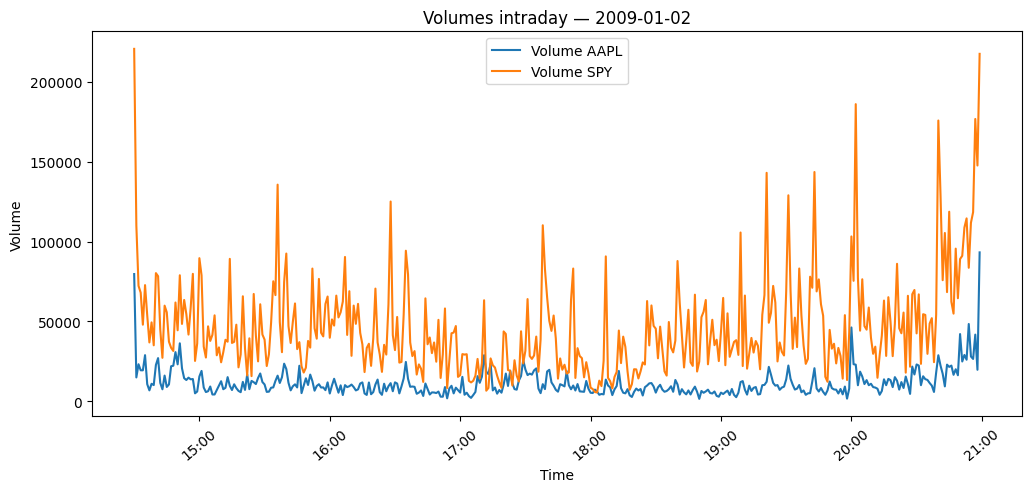

In [73]:
day = df_merged["datetime"][0].date()
df_day = df_merged.filter(pl.col("datetime").dt.date() == day)

plt.figure(figsize=(12,5))
plt.plot(df_day["datetime"], df_day["volume_AAPL"], label="Volume AAPL")
plt.plot(df_day["datetime"], df_day["volume_SPY"], label="Volume SPY")
plt.title(f"Volumes intraday — {day}")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)
plt.show()

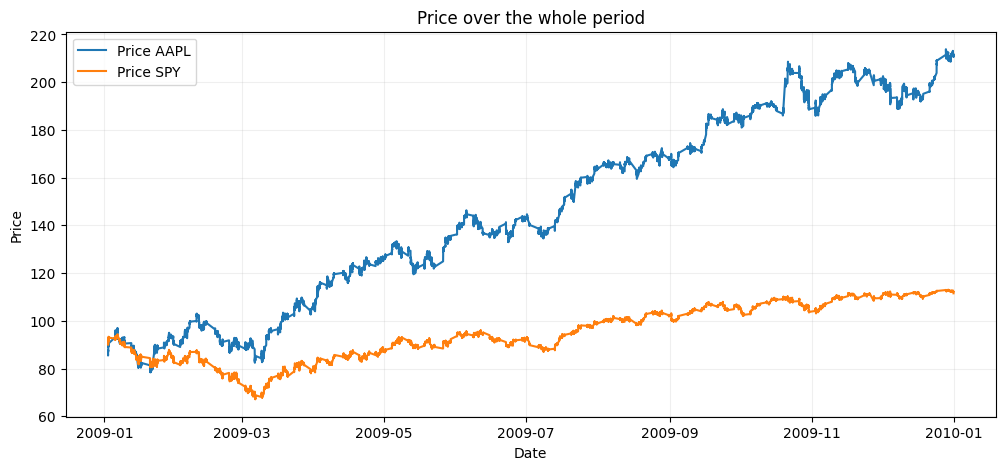

In [74]:
plt.figure(figsize=(12,5))
plt.plot(df_merged["datetime"], df_merged["price_AAPL"], label="Price AAPL")
plt.plot(df_merged["datetime"], df_merged["price_SPY"], label="Price SPY")
plt.title(f"Price over the whole period")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

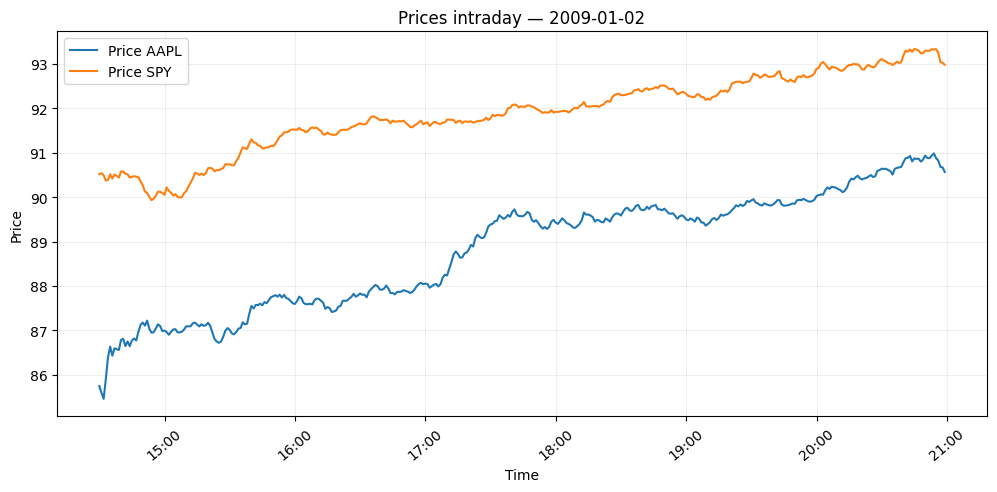

In [75]:
day = df_merged["datetime"][0].date()
df_day = df_merged.filter(pl.col("datetime").dt.date() == day)

plt.figure(figsize=(12,5))
plt.plot(df_day["datetime"], df_day["price_AAPL"], label="Price AAPL")
plt.plot(df_day["datetime"], df_day["price_SPY"], label="Price SPY")
plt.title(f"Prices intraday — {day}")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)
plt.show()

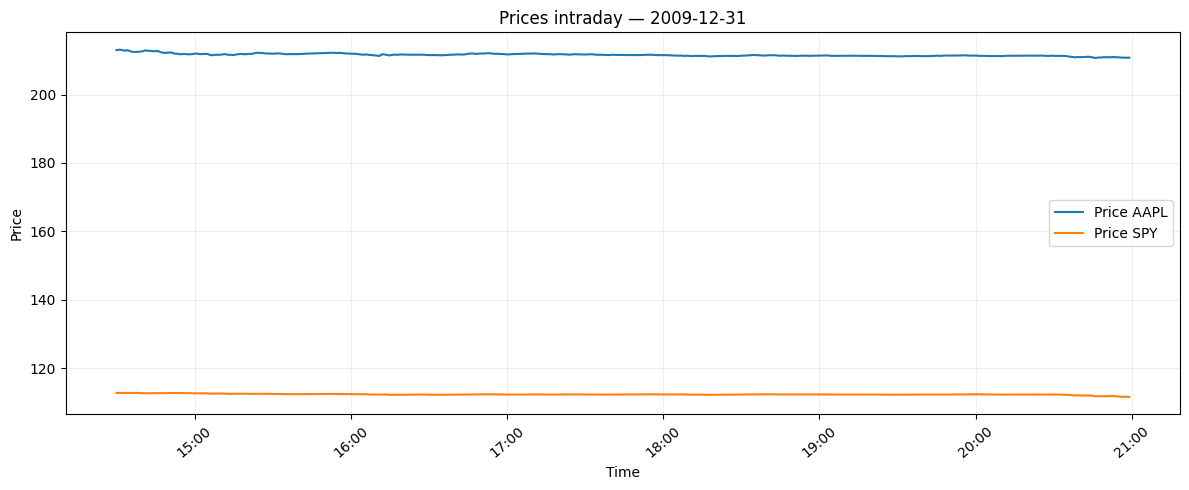

In [76]:
last_day = df_merged["datetime"][-1].date()

df_last = df_merged.filter(pl.col("datetime").dt.date() == last_day)

plt.figure(figsize=(12,5))
plt.plot(df_last["datetime"], df_last["price_AAPL"], label="Price AAPL")
plt.plot(df_last["datetime"], df_last["price_SPY"], label="Price SPY")
plt.title(f"Prices intraday — {last_day}")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

## return


In [121]:
df_returns = (
    df_merged
    .with_columns([
        (pl.col("price_AAPL").log() - pl.col("price_AAPL").log().shift(1)).alias("ret_AAPL"),
        (pl.col("price_SPY").log() - pl.col("price_SPY").log().shift(1)).alias("ret_SPY"),
    ])
    .drop_nulls(subset=["ret_AAPL", "ret_SPY"])  # supprime la première ligne
)

In [122]:
ret_AAPL_mean = df_returns["ret_AAPL"].mean()
ret_AAPL_std = df_returns["ret_AAPL"].std()
ret_SPY_mean = df_returns["ret_SPY"].mean()
ret_SPY_std = df_returns["ret_SPY"].std()
volume_AAPL_mean = df_returns["volume_AAPL"].mean()
volume_AAPL_std = df_returns["volume_AAPL"].std()
volume_SPY_mean = df_returns["volume_SPY"].mean()
volume_SPY_std = df_returns["volume_SPY"].std()
print(f"AAPL Return Mean: {ret_AAPL_mean}, Std: {ret_AAPL_std}")
print(f"SPY Return Mean: {ret_SPY_mean}, Std: {ret_SPY_std}")
print(f"AAPL Volume Mean: {volume_AAPL_mean}, Std: {volume_AAPL_std}")
print(f"SPY Volume Mean: {volume_SPY_mean}, Std: {volume_SPY_std}")
print("Let's normalize and center the returns and volumes.")

df_returns = df_returns.with_columns([
    ((pl.col("ret_AAPL") - ret_AAPL_mean) / ret_AAPL_std).alias("ret_AAPL"),
    ((pl.col("ret_SPY") - ret_SPY_mean) / ret_SPY_std).alias("ret_SPY"),
    ((pl.col("volume_AAPL") - volume_AAPL_mean) / volume_AAPL_std).alias("volume_AAPL"),
    ((pl.col("volume_SPY") - volume_SPY_mean) / volume_SPY_std).alias("volume_SPY"),
])
df_returns = df_returns.select(["datetime", "price_AAPL", "ret_AAPL", "volume_AAPL", "price_SPY", "ret_SPY", "volume_SPY"])

AAPL Return Mean: 9.183540967833837e-06, Std: 0.0009550324083282326
SPY Return Mean: 2.13179265725376e-06, Std: 0.0007289865442077745
AAPL Volume Mean: 9108.462143318828, Std: 25356.31301878156
SPY Volume Mean: 38467.219559899066, Std: 36874.77353234921
Let's normalize and center the returns and volumes.


In [123]:
print(df_returns.head())

shape: (5, 7)
┌──────────────────────┬────────────┬───────────┬─────────────┬───────────┬───────────┬────────────┐
│ datetime             ┆ price_AAPL ┆ ret_AAPL  ┆ volume_AAPL ┆ price_SPY ┆ ret_SPY   ┆ volume_SPY │
│ ---                  ┆ ---        ┆ ---       ┆ ---         ┆ ---       ┆ ---       ┆ ---        │
│ datetime[μs,         ┆ f64        ┆ f64       ┆ f64         ┆ f64       ┆ f64       ┆ f64        │
│ America/New_York]    ┆            ┆           ┆             ┆           ┆           ┆            │
╞══════════════════════╪════════════╪═══════════╪═════════════╪═══════════╪═══════════╪════════════╡
│ 2009-01-02 09:31:00  ┆ 85.5945    ┆ -1.88463  ┆ 0.231163    ┆ 90.541658 ┆ 0.359195  ┆ 1.940532   │
│ EST                  ┆            ┆           ┆             ┆           ┆           ┆            │
│ 2009-01-02 09:32:00  ┆ 85.459586  ┆ -1.661339 ┆ 0.556613    ┆ 90.493477 ┆ -0.733086 ┆ 0.917293   │
│ EST                  ┆            ┆           ┆             ┆           ┆  

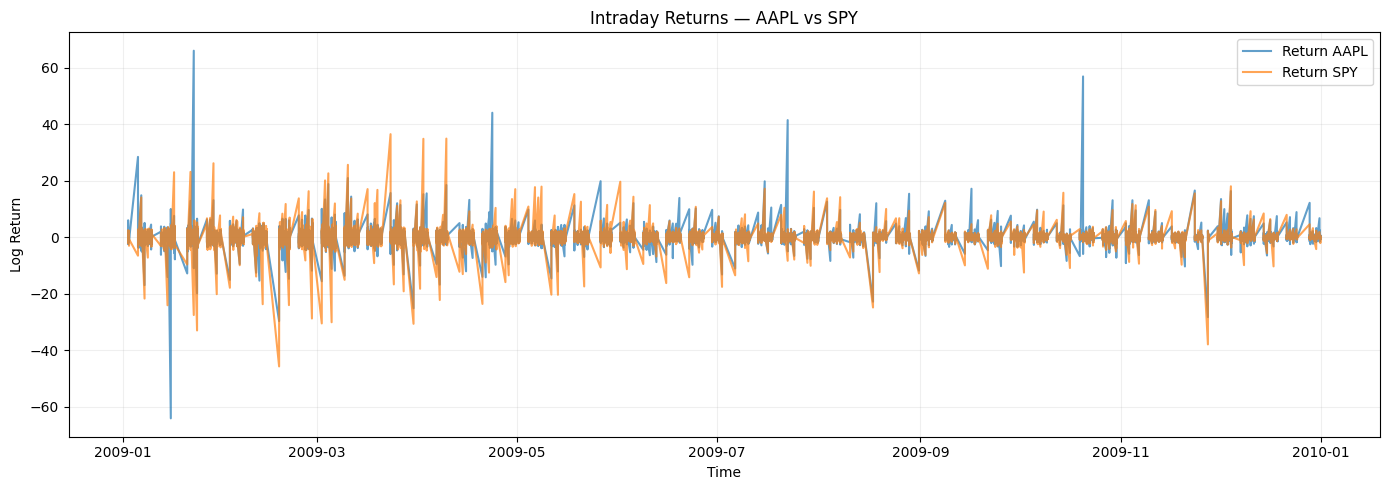

In [124]:
plt.figure(figsize=(14,5))
plt.plot(df_returns["datetime"], df_returns["ret_AAPL"], label="Return AAPL", alpha=0.7)
plt.plot(df_returns["datetime"], df_returns["ret_SPY"], label="Return SPY", alpha=0.7)
plt.title("Intraday Returns — AAPL vs SPY")
plt.xlabel("Time")
plt.ylabel("Log Return")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

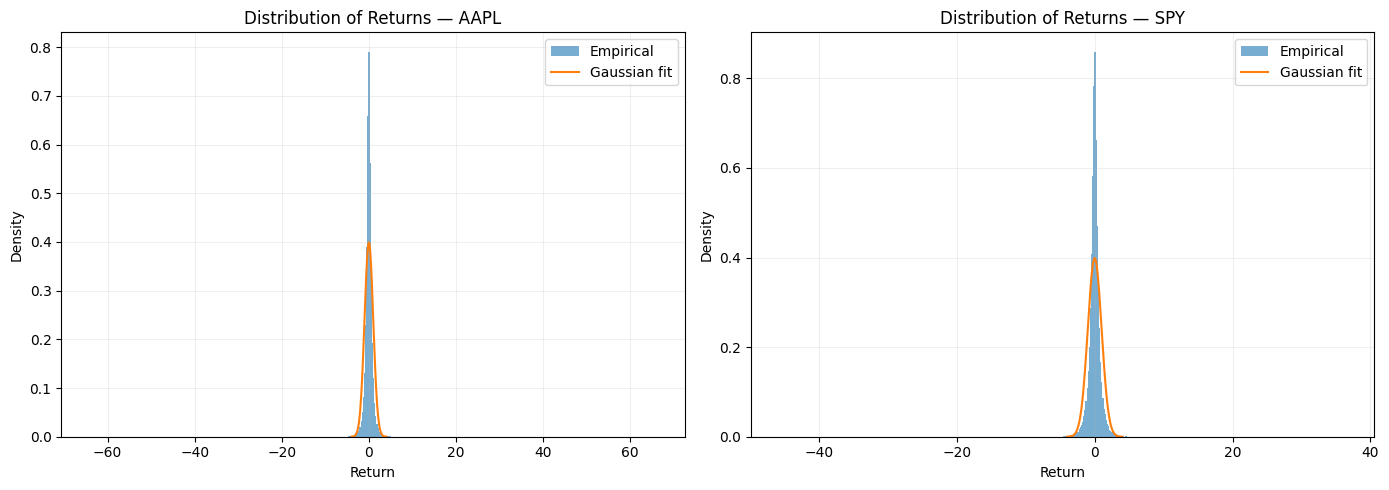

In [125]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

for i, (data, name) in enumerate([(df_returns["ret_AAPL"].to_numpy(), "AAPL"),(df_returns["ret_SPY"].to_numpy(), "SPY")]):
    mu, sigma = np.mean(data), np.std(data)
    ax[i].hist(data, bins=500, density=True, alpha=0.6, label="Empirical")
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    ax[i].plot(x, norm.pdf(x, mu, sigma), label="Gaussian fit")
    ax[i].set_title(f"Distribution of Returns — {name}")
    ax[i].set_xlabel("Return")
    ax[i].set_ylabel("Density")
    ax[i].legend()
    ax[i].grid(alpha=0.2)
plt.tight_layout()
plt.show()

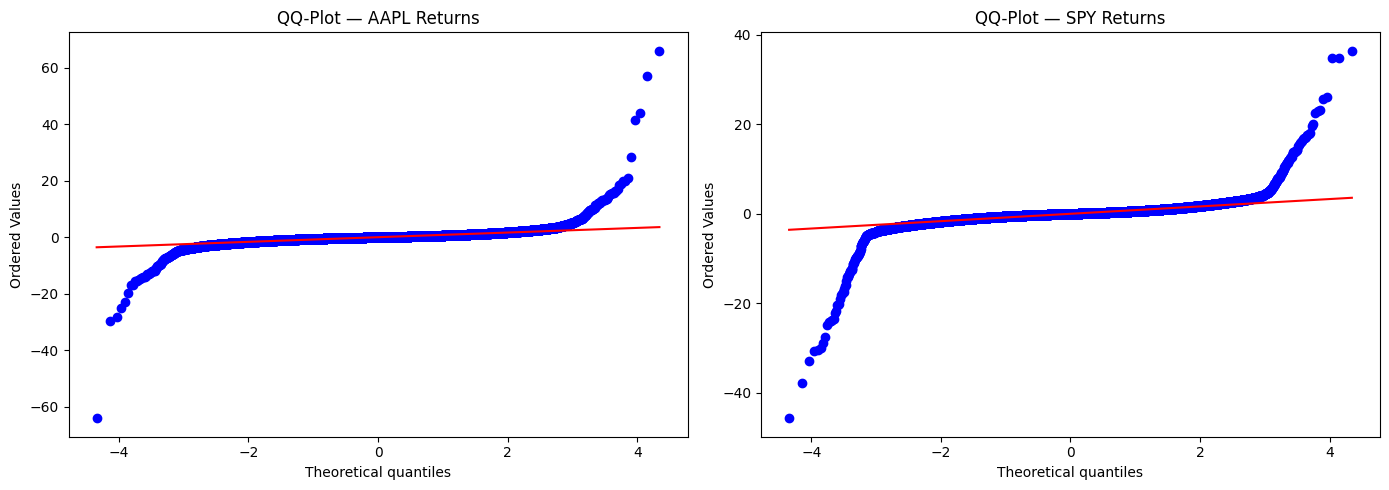

In [126]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
stats.probplot(df_returns["ret_AAPL"], dist="norm", plot=ax[0])
ax[0].set_title("QQ-Plot — AAPL Returns")
stats.probplot(df_returns["ret_SPY"], dist="norm", plot=ax[1])
ax[1].set_title("QQ-Plot — SPY Returns")
plt.tight_layout()
plt.show()

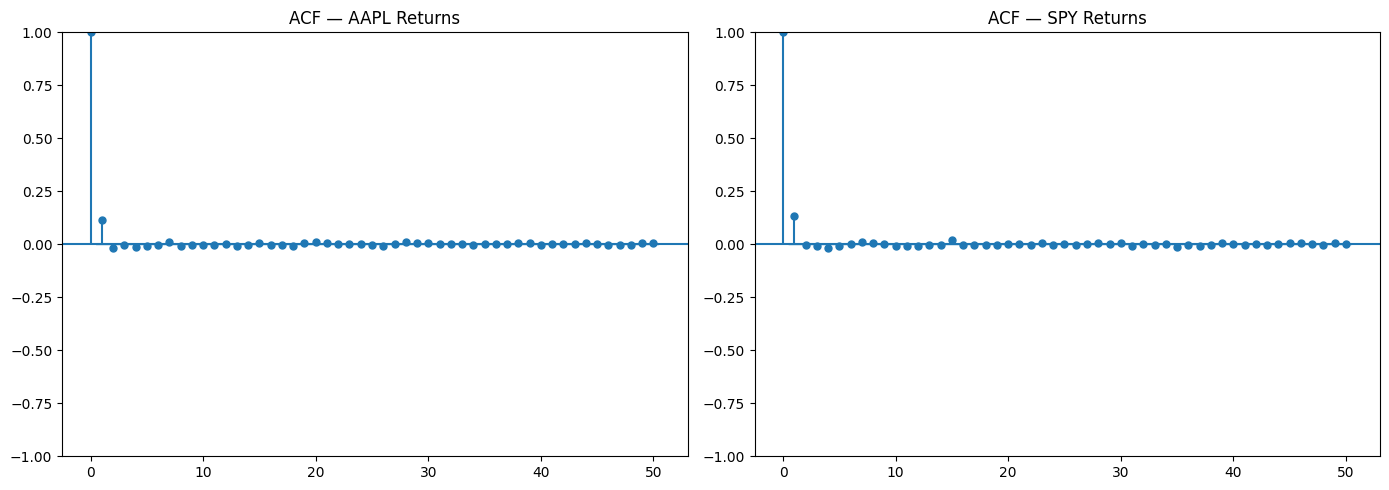

In [127]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
plot_acf(df_returns["ret_AAPL"], ax=ax[0], lags=50)
ax[0].set_title("ACF — AAPL Returns")
plot_acf(df_returns["ret_SPY"], ax=ax[1], lags=50)
ax[1].set_title("ACF — SPY Returns")

plt.tight_layout()
plt.show()

## Cross Corellation (with and witout lag)

In [128]:
def cross_corr_at_lag(ret_aapl, ret_spy, lag):
    """
    Compute correlation between ret_AAPL(t+lag) and ret_SPY(t)
    lag > 0  -> test if SPY leads AAPL
    lag < 0  -> test if AAPL leads SPY
    """
    rA = ret_aapl.to_numpy()
    rS = ret_spy.to_numpy()
    if lag > 0:
        return np.corrcoef(rA[lag:], rS[:-lag])[0, 1]
    elif lag < 0:
        lag = -lag
        return np.corrcoef(rA[:-lag], rS[lag:])[0, 1]
    else:
        return np.corrcoef(rA, rS)[0, 1]

In [129]:
lags = range(-10, 11)  # -10 à +10
cc_values = [cross_corr_at_lag(df_returns["ret_AAPL"], df_returns["ret_SPY"], lag) for lag in lags]

In [130]:
cc_table = pd.DataFrame({"lag": list(lags),"cross_corr": cc_values})
print(cc_table)

    lag  cross_corr
0   -10    0.000556
1    -9    0.002690
2    -8    0.000082
3    -7    0.006252
4    -6    0.001698
5    -5   -0.000064
6    -4   -0.007631
7    -3    0.002238
8    -2    0.005667
9    -1    0.099105
10    0    0.603380
11    1    0.063345
12    2   -0.020168
13    3   -0.010194
14    4   -0.016297
15    5   -0.011084
16    6   -0.005924
17    7    0.008351
18    8    0.005545
19    9   -0.005115
20   10   -0.002982


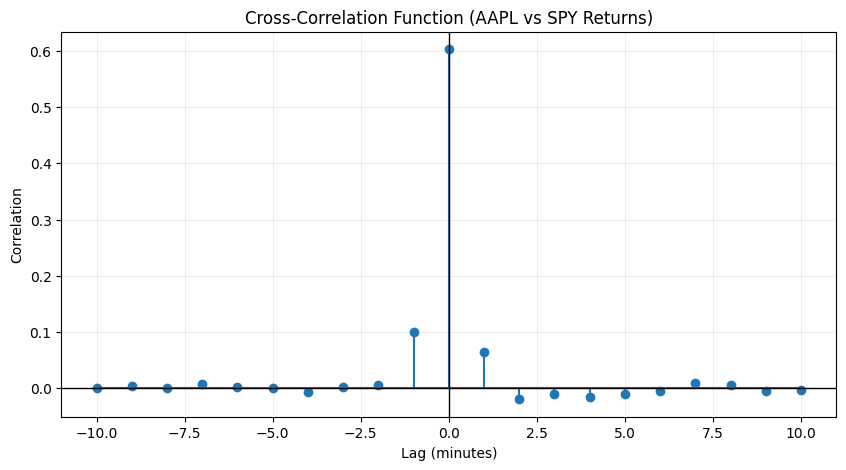

In [131]:
plt.figure(figsize=(10,5))
plt.stem(lags, cc_values)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title("Cross-Correlation Function (AAPL vs SPY Returns)")
plt.xlabel("Lag (minutes)")
plt.ylabel("Correlation")
plt.grid(alpha=0.2)
plt.show()

## Not much things to say in minute -> let's analyse it in secondes 

In [132]:
def bucket_1sec(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by_dynamic(
            "datetime",
            every="1s",    
            period="1s",
            closed="left",
            label="left",
        )
        .agg([
            pl.col("price").mean().alias("price"),
            pl.col("volume").sum().alias("volume"),
        ])
        .sort("datetime")
    )

In [133]:
df1_sec = bucket_1sec(df)
df2_sec = bucket_1sec(df1)
df1_sec = df1_sec.rename({"price": "price_AAPL","volume": "volume_AAPL"})

In [134]:
df_merged_sec = (df1_sec.join(df2_sec, on="datetime", how="inner").rename({"price": "price_SPY","volume": "volume_SPY",}).select(["datetime","price_AAPL","volume_AAPL","price_SPY","volume_SPY",]))

In [135]:
df_returns_sec = (df_merged_sec.with_columns([(pl.col("price_AAPL").log() - pl.col("price_AAPL").log().shift(1)).alias("ret_AAPL"),(pl.col("price_SPY").log()  - pl.col("price_SPY").log().shift(1)).alias("ret_SPY"),]).drop_nulls(subset=["ret_AAPL", "ret_SPY"]))

In [136]:
df_returns_sec = df_returns_sec.with_columns([
    ((pl.col("ret_AAPL") - pl.col("ret_AAPL").mean()) / pl.col("ret_AAPL").std()).alias("ret_AAPL"),
    ((pl.col("ret_SPY") - pl.col("ret_SPY").mean()) / pl.col("ret_SPY").std()).alias("ret_SPY"),
    ((pl.col("volume_AAPL") - pl.col("volume_AAPL").mean()) / pl.col("volume_AAPL").std()).alias("volume_AAPL"),
    ((pl.col("volume_SPY") - pl.col("volume_SPY").mean()) / pl.col("volume_SPY").std()).alias("volume_SPY"),
])
df_returns_sec = df_returns_sec.select(["datetime", "price_AAPL", "ret_AAPL", "volume_AAPL", "price_SPY", "ret_SPY", "volume_SPY"])

In [137]:
print(df_returns_sec.head())

shape: (5, 7)
┌──────────────────────┬────────────┬───────────┬─────────────┬───────────┬───────────┬────────────┐
│ datetime             ┆ price_AAPL ┆ ret_AAPL  ┆ volume_AAPL ┆ price_SPY ┆ ret_SPY   ┆ volume_SPY │
│ ---                  ┆ ---        ┆ ---       ┆ ---         ┆ ---       ┆ ---       ┆ ---        │
│ datetime[μs,         ┆ f64        ┆ f64       ┆ f64         ┆ f64       ┆ f64       ┆ f64        │
│ America/New_York]    ┆            ┆           ┆             ┆           ┆           ┆            │
╞══════════════════════╪════════════╪═══════════╪═════════════╪═══════════╪═══════════╪════════════╡
│ 2009-01-02 09:30:02  ┆ 85.553333  ┆ -2.028579 ┆ -0.046567   ┆ 90.5      ┆ 3.116259  ┆ 0.659812   │
│ EST                  ┆            ┆           ┆             ┆           ┆           ┆            │
│ 2009-01-02 09:30:03  ┆ 85.5825    ┆ 1.311096  ┆ 0.041824    ┆ 90.444559 ┆ -3.200927 ┆ 6.974118   │
│ EST                  ┆            ┆           ┆             ┆           ┆  

In [138]:
def cross_corr_at_lag(ret_aapl, ret_spy, lag_sec: int) -> float:
    """
    Corr( ret_AAPL(t + lag), ret_SPY(t) )
    lag_sec > 0  -> SPY lead AAPL
    lag_sec < 0  -> AAPL lead SPY
    """
    rA = ret_aapl.to_numpy()
    rS = ret_spy.to_numpy()
    if lag_sec > 0:
        return np.corrcoef(rA[lag_sec:], rS[:-lag_sec])[0, 1]
    elif lag_sec < 0:
        lag = -lag_sec
        return np.corrcoef(rA[:-lag], rS[lag:])[0, 1]
    else:
        return np.corrcoef(rA, rS)[0, 1]

In [139]:
lags = range(-60, 61)
cc_values = [cross_corr_at_lag(df_returns_sec["ret_AAPL"], df_returns_sec["ret_SPY"], lag)for lag in lags]

In [140]:
cc_table = pd.DataFrame({"lag_sec": list(lags), "corr": cc_values})
cc_table_sorted = cc_table.sort_values("corr", ascending=False)
print(cc_table_sorted.head(10))

    lag_sec      corr
60        0  0.474816
59       -1  0.135003
61        1  0.094523
58       -2  0.020273
62        2  0.013612
57       -3  0.006576
63        3  0.004341
45      -15  0.002200
56       -4  0.002112
46      -14  0.001652


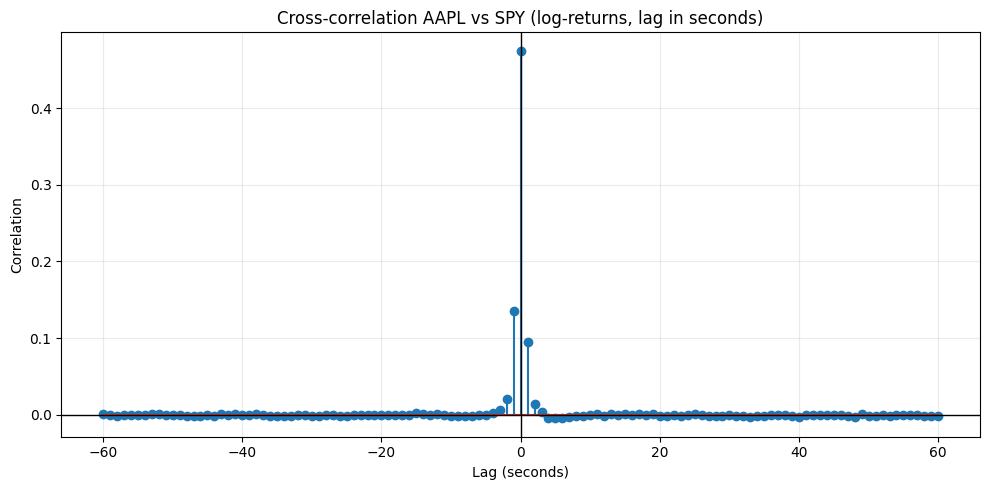

In [141]:
plt.figure(figsize=(10,5))
plt.stem(lags, cc_values)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title("Cross-correlation AAPL vs SPY (log-returns, lag in seconds)")
plt.xlabel("Lag (seconds)")
plt.ylabel("Correlation")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Only the first few secondes have non neglegeable correlation

## Relation volume - Price


In [142]:
corr_priceAAPL_volSPY = np.corrcoef(df_returns["price_AAPL"].to_numpy(),df_returns["volume_SPY"].to_numpy())[0, 1]
corr_priceSPY_volAAPL = np.corrcoef(df_returns["price_SPY"].to_numpy(),df_returns["volume_AAPL"].to_numpy())[0, 1]
print("Corr(price_AAPL, volume_SPY):", corr_priceAAPL_volSPY)
print("Corr(price_SPY, volume_AAPL):", corr_priceSPY_volAAPL)

Corr(price_AAPL, volume_SPY): -0.39878253810331354
Corr(price_SPY, volume_AAPL): -0.060801827546551064


A negative correlation -> when SPY volume spikes, AAPL price tends to fall.

In [143]:
corr_retAAPL_volSPY = np.corrcoef(df_returns["ret_AAPL"].to_numpy(),df_returns["volume_SPY"].to_numpy())[0, 1]
corr_retSPY_volAAPL = np.corrcoef(df_returns["ret_SPY"].to_numpy(),df_returns["volume_AAPL"].to_numpy())[0, 1]
print("Corr(ret_AAPL, volume_SPY):", corr_retAAPL_volSPY)
print("Corr(ret_SPY, volume_AAPL):", corr_retSPY_volAAPL)

Corr(ret_AAPL, volume_SPY): 0.012872109717445363
Corr(ret_SPY, volume_AAPL): 0.0014507825213485991


## With Lags


In [144]:
def corr_vol_price_lag(vol_series, price_series, lag):
    v = vol_series.to_numpy()
    p = price_series.to_numpy()
    if lag > 0:
        return np.corrcoef(v[:-lag], p[lag:])[0, 1]
    elif lag < 0:
        lag = -lag
        return np.corrcoef(v[lag:], p[:-lag])[0, 1]
    else:
        return np.corrcoef(v, p)[0, 1]

In [145]:
lags = range(-10, 11)
cc_volSPY_retAAPL = [corr_vol_price_lag(df_returns["volume_SPY"], df_returns["ret_AAPL"], lag)for lag in lags]

In [146]:
cc_volAAPL_retSPY = [corr_vol_price_lag(df_returns["volume_AAPL"], df_returns["ret_SPY"], lag)for lag in lags]

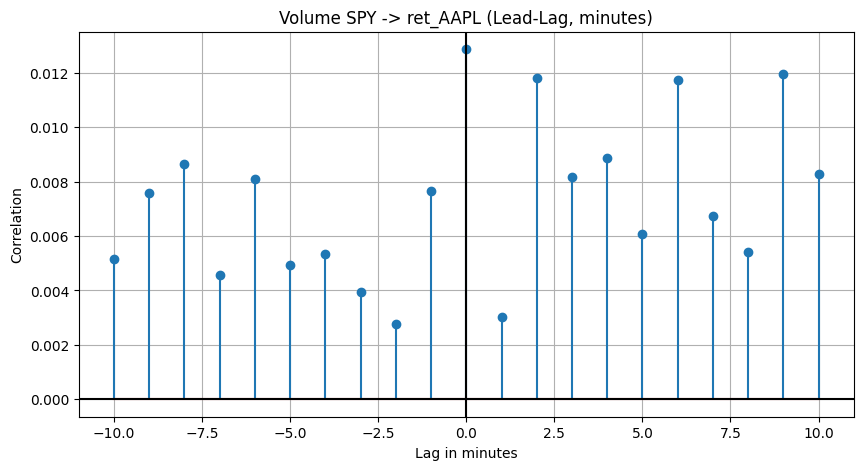

In [147]:
plt.figure(figsize=(10,5))
plt.stem(lags, cc_volSPY_retAAPL)
plt.axhline(0, color="black")
plt.axvline(0, color="black")
plt.title("Volume SPY -> ret_AAPL (Lead-Lag, minutes)")
plt.xlabel("Lag in minutes")
plt.ylabel("Correlation")
plt.grid()
plt.show()

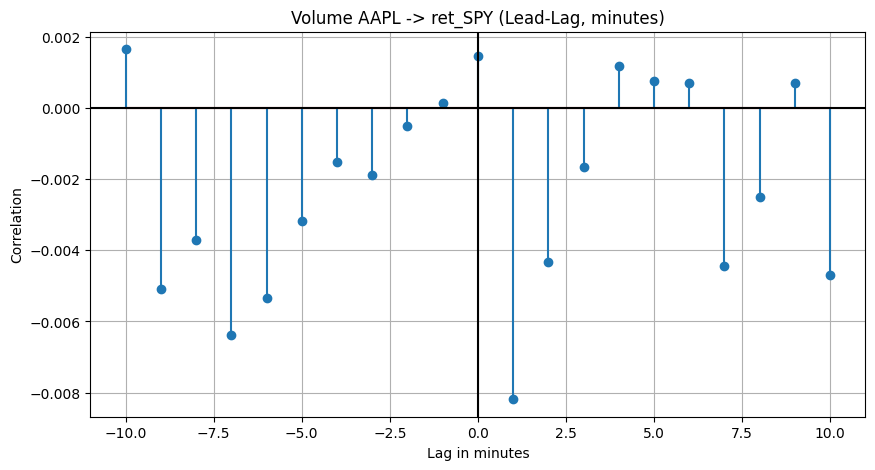

In [148]:
plt.figure(figsize=(10,5))
plt.stem(lags, cc_volAAPL_retSPY)
plt.axhline(0, color="black")
plt.axvline(0, color="black")
plt.title("Volume AAPL -> ret_SPY (Lead-Lag, minutes)")
plt.xlabel("Lag in minutes")
plt.ylabel("Correlation")
plt.grid()
plt.show()

## Rolling Windows

In [149]:
#Rolling correlations ret_AAPL, ret_SPY (30m, 60m, 1d)
df_roll = (
    df_returns
    .with_columns([
        pl.rolling_corr(pl.col("ret_AAPL"),pl.col("ret_SPY"),window_size=30).alias("roll_corr_30m"),
        pl.rolling_corr(pl.col("ret_AAPL"),pl.col("ret_SPY"),window_size=60).alias("roll_corr_60m"),
        pl.rolling_corr(pl.col("ret_AAPL"),pl.col("ret_SPY"),window_size=390).alias("roll_corr_1d"),
    ])
)

In [150]:
#Rolling lead–lag correlation (lags −1, 0, +1 minute)
df_roll = (
    df_roll
    .with_columns([
        pl.rolling_corr(pl.col("ret_AAPL"),pl.col("ret_SPY").shift(-1),window_size=60).alias("lag_m1"),
        pl.rolling_corr(pl.col("ret_AAPL"),pl.col("ret_SPY"),window_size=60).alias("lag_0"),
        pl.rolling_corr(pl.col("ret_AAPL"),pl.col("ret_SPY").shift(1),window_size=60).alias("lag_p1"),
    ])
)

In [151]:
df_roll = (
    df_roll
    .with_columns([
        pl.rolling_corr(pl.col("volume_SPY"),pl.col("ret_AAPL"),window_size=30).alias("volSPY_retAAPL_30m"),
        pl.rolling_corr(pl.col("volume_AAPL"),pl.col("ret_SPY"),window_size=30).alias("volAAPL_retSPY_30m"),
    ])
)

In [152]:
df_roll.head(5)

datetime,price_AAPL,ret_AAPL,volume_AAPL,price_SPY,ret_SPY,volume_SPY,roll_corr_30m,roll_corr_60m,roll_corr_1d,lag_m1,lag_0,lag_p1,volSPY_retAAPL_30m,volAAPL_retSPY_30m
"datetime[μs, America/New_York]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2009-01-02 09:31:00 EST,85.5945,-1.88463,0.231163,90.541658,0.359195,1.940532,null,null,null,null,null,null,null,null
2009-01-02 09:32:00 EST,85.459586,-1.661339,0.556613,90.493477,-0.733086,0.917293,null,null,null,null,null,null,null,null
2009-01-02 09:33:00 EST,85.902588,5.404207,0.407498,90.374865,-1.802112,0.800705,null,null,null,null,null,null,null,null
2009-01-02 09:34:00 EST,86.395578,5.982359,0.406694,90.391746,0.25328,0.257932,null,null,null,null,null,null,null,null
2009-01-02 09:35:00 EST,86.635535,2.894556,0.780764,90.516698,1.892009,0.929565,null,null,null,null,null,null,null,null


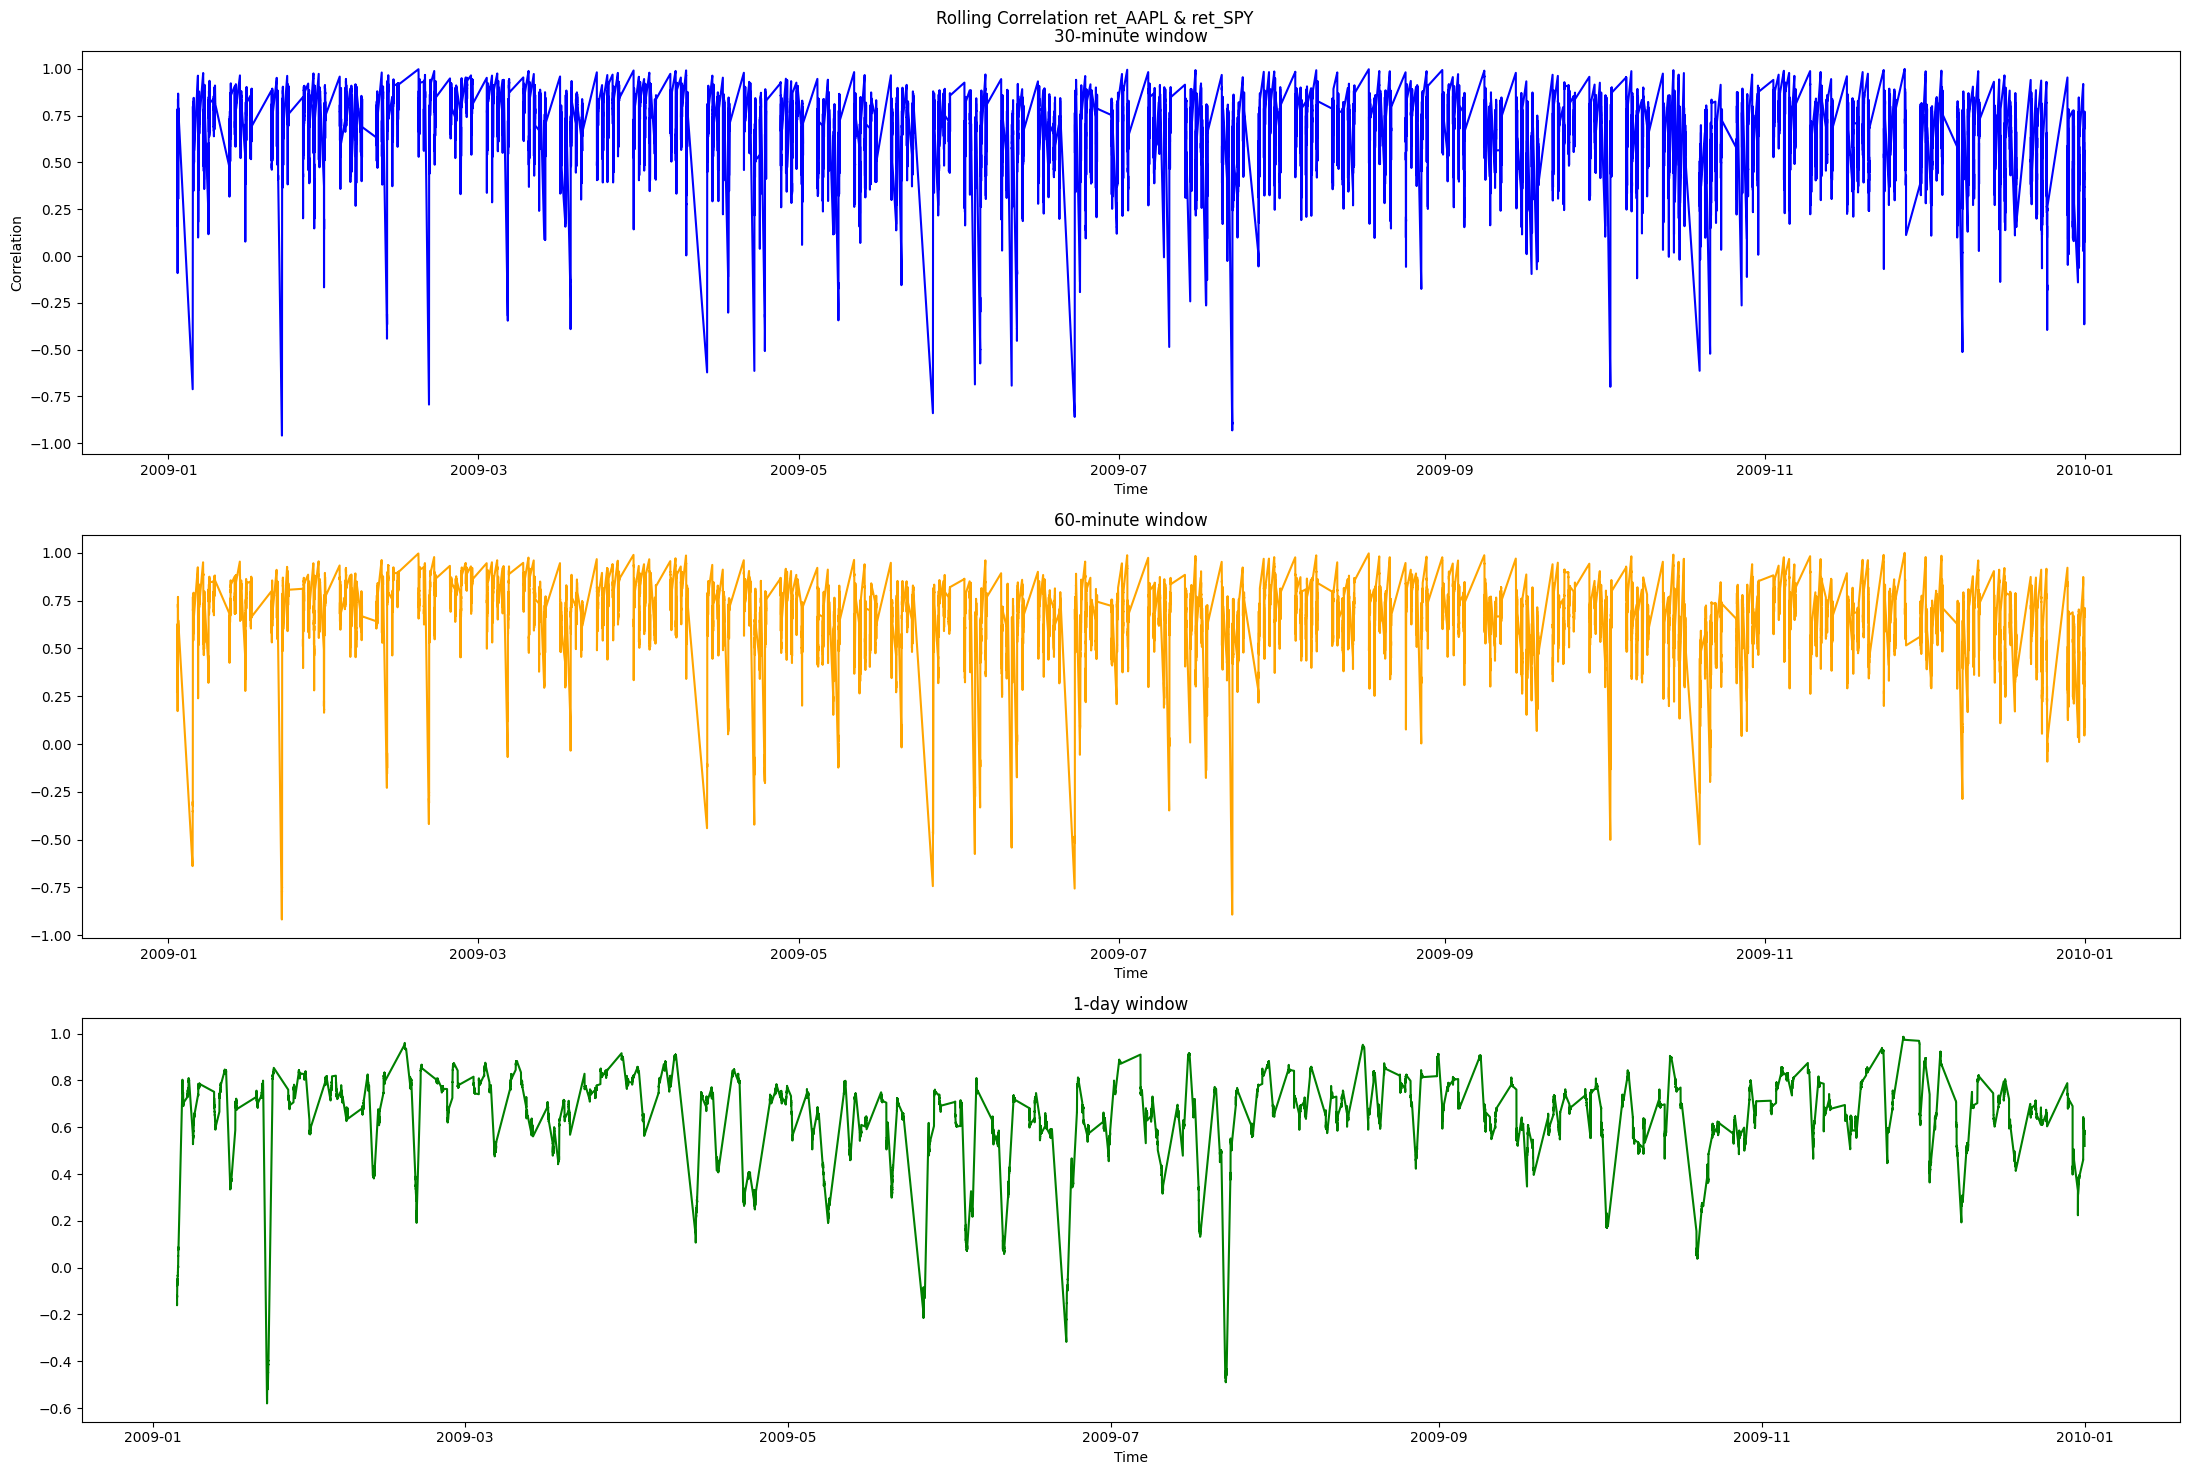

In [153]:
t = df_roll["datetime"].to_numpy()
fig, axes = plt.subplots(3, 1, figsize=(22, 15))
fig.suptitle("Rolling Correlation ret_AAPL & ret_SPY")
axes[0].plot(t, df_roll["roll_corr_30m"].to_numpy(), color="blue")
axes[0].set_title("30-minute window")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Correlation")
axes[1].plot(t, df_roll["roll_corr_60m"].to_numpy(), color="orange")
axes[1].set_title("60-minute window")
axes[1].set_xlabel("Time")
axes[2].plot(t, df_roll["roll_corr_1d"].to_numpy(), color="green")
axes[2].set_title("1-day window")
axes[2].set_xlabel("Time")
plt.tight_layout()
plt.show()

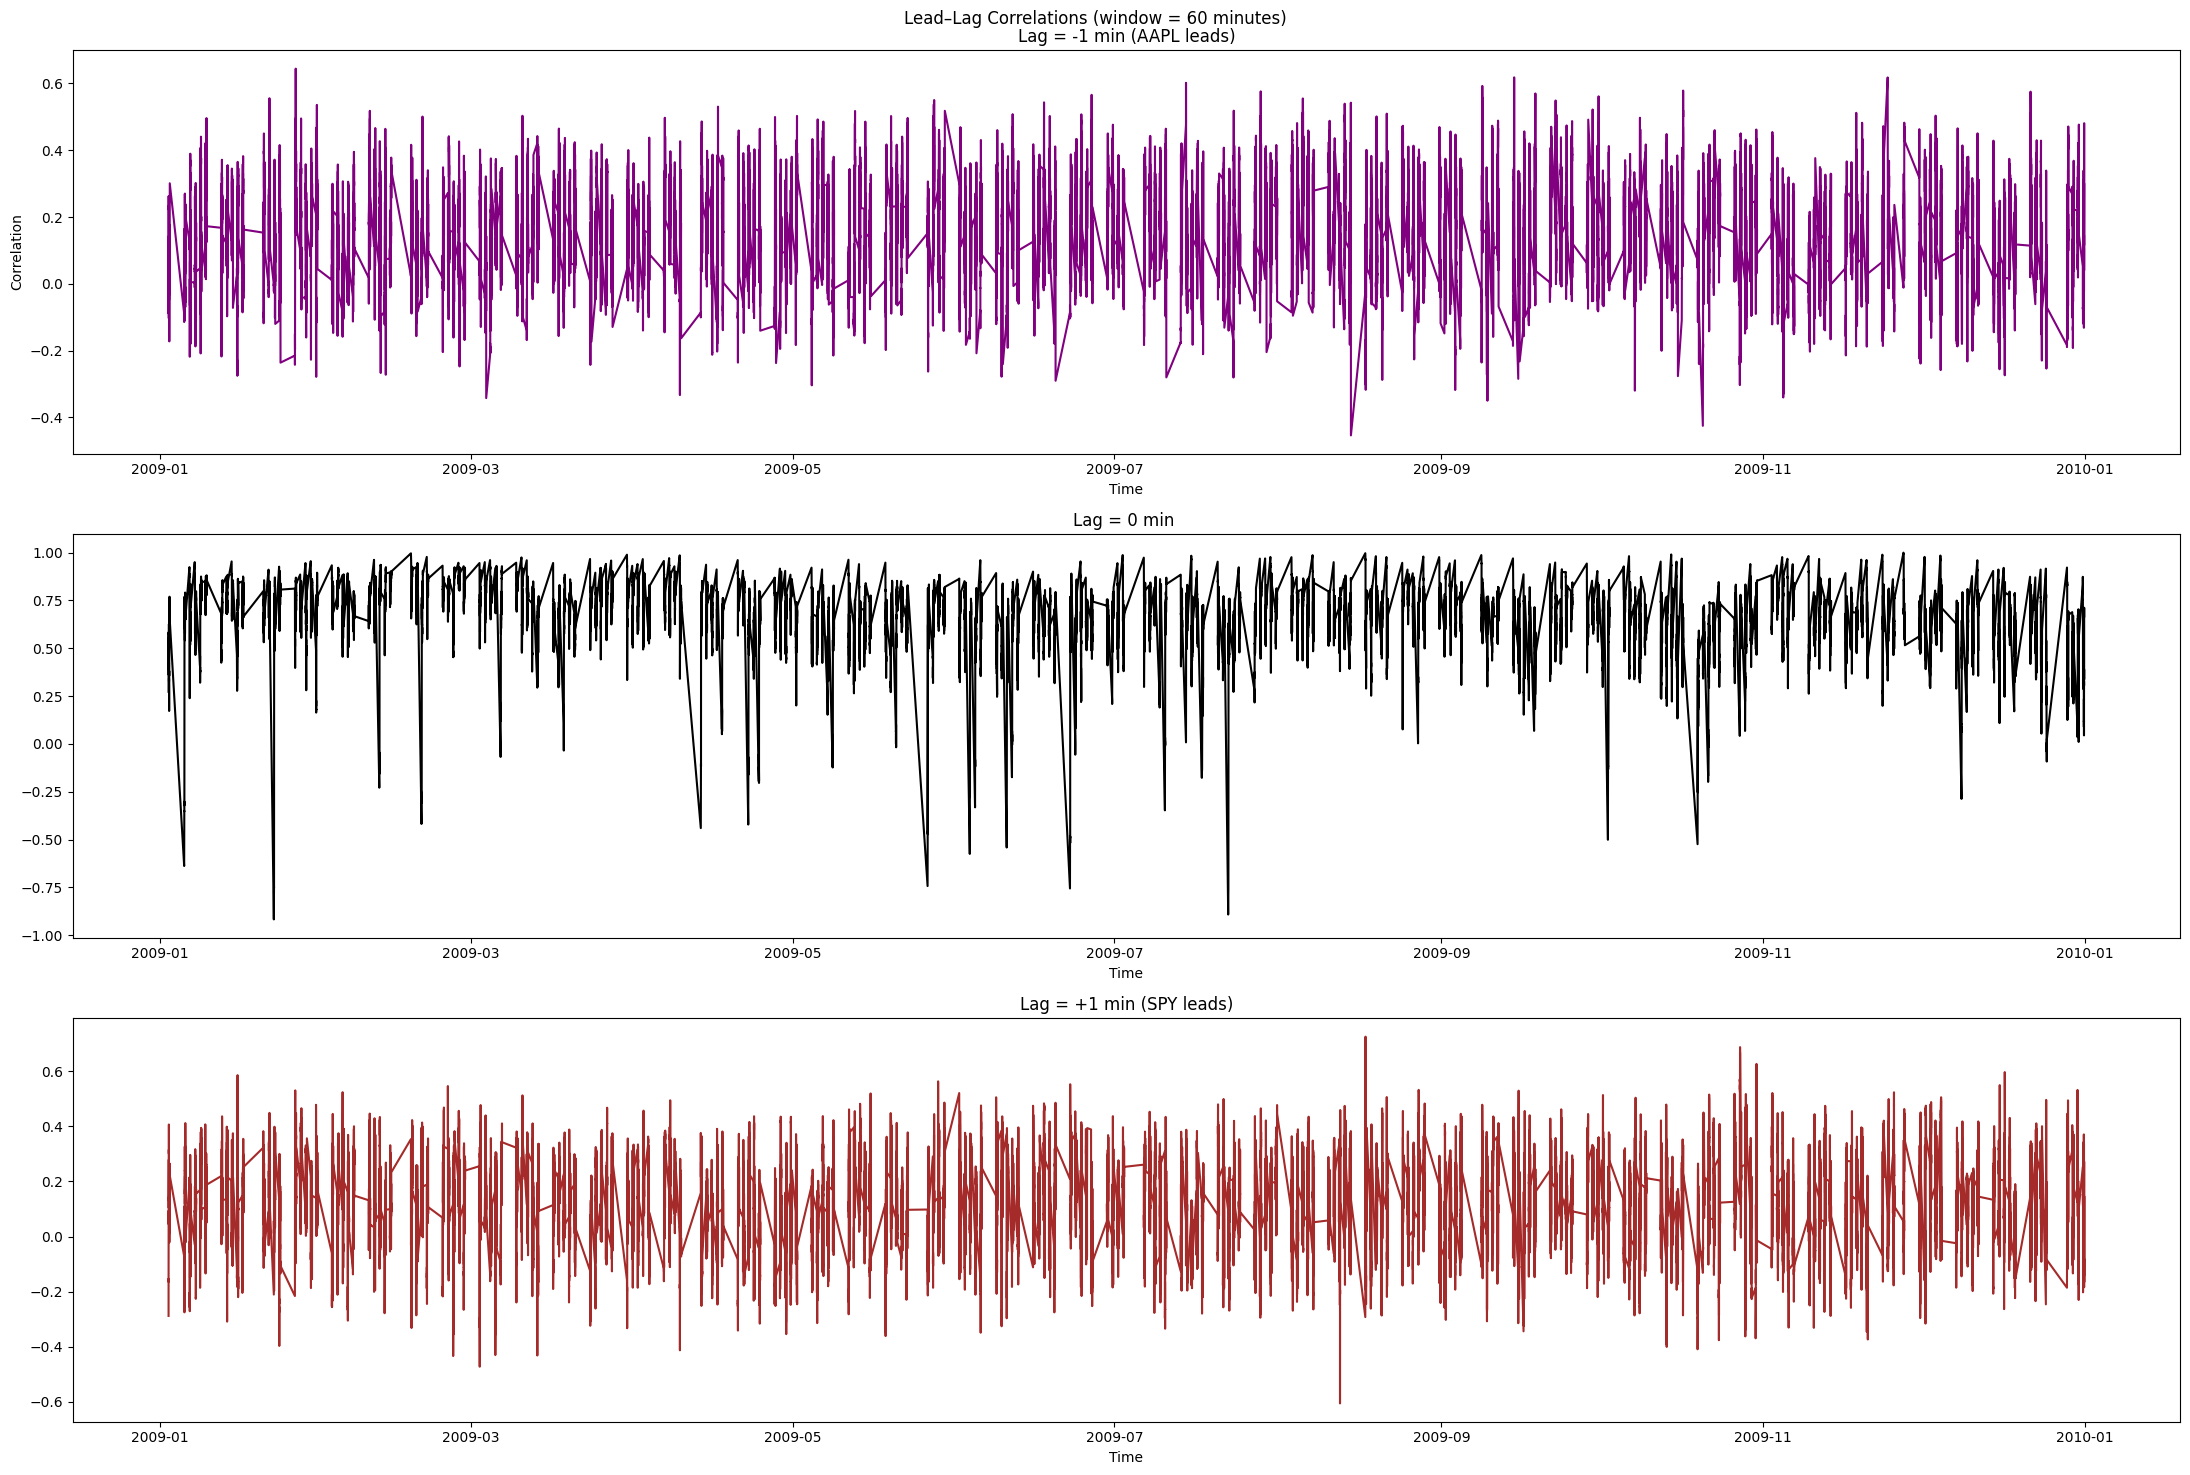

In [154]:
fig, axes = plt.subplots(3, 1, figsize=(22, 15))
fig.suptitle("Lead–Lag Correlations (window = 60 minutes)")
axes[0].plot(t, df_roll["lag_m1"].to_numpy(), color="purple")
axes[0].set_title("Lag = -1 min (AAPL leads)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Correlation")
axes[1].plot(t, df_roll["lag_0"].to_numpy(), color="black")
axes[1].set_title("Lag = 0 min ")
axes[1].set_xlabel("Time")
axes[2].plot(t, df_roll["lag_p1"].to_numpy(), color="brown")
axes[2].set_title("Lag = +1 min (SPY leads)")
axes[2].set_xlabel("Time")
plt.tight_layout()
plt.show()

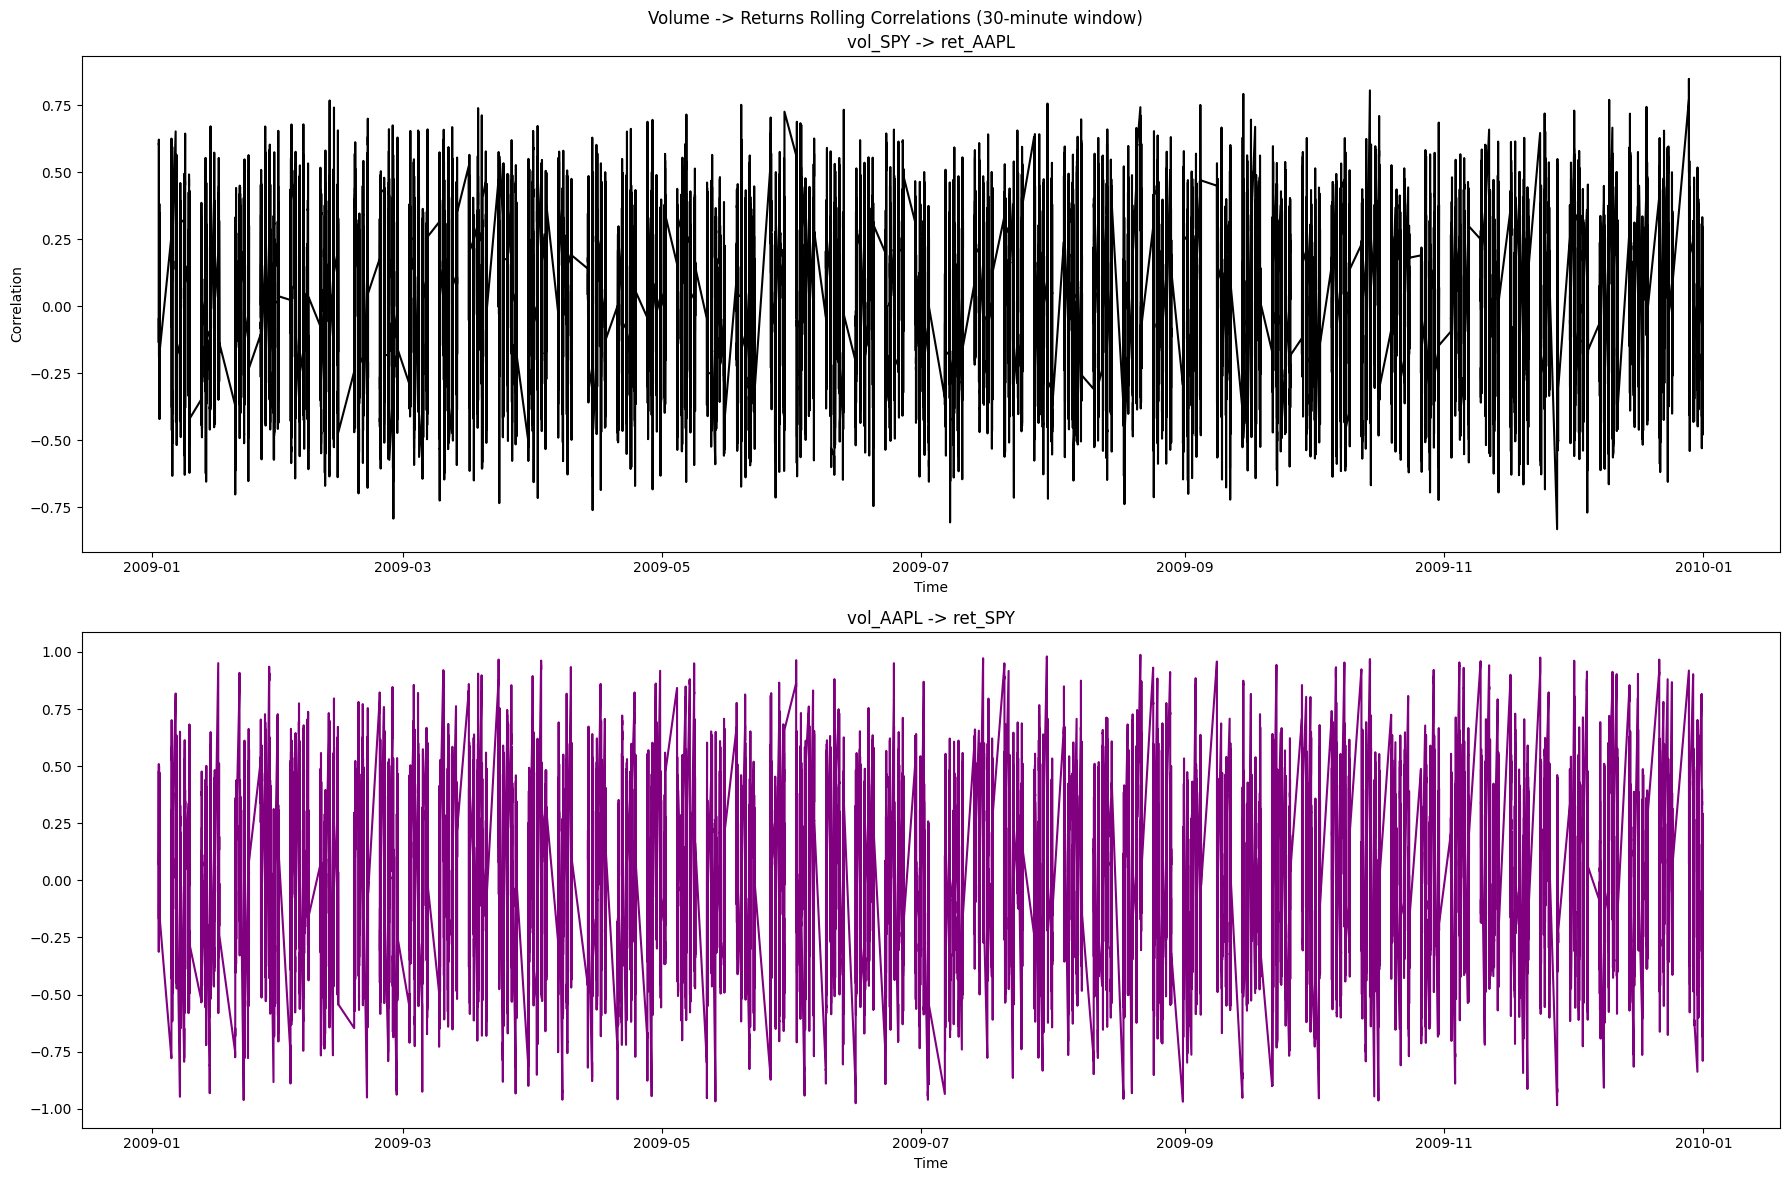

In [155]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle("Volume -> Returns Rolling Correlations (30-minute window)")
axes[0].plot(t, df_roll["volSPY_retAAPL_30m"].to_numpy(), color="black")
axes[0].set_title("vol_SPY -> ret_AAPL")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Correlation")
axes[1].plot(t, df_roll["volAAPL_retSPY_30m"].to_numpy(), color="purple")
axes[1].set_title("vol_AAPL -> ret_SPY")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Difference between returns

In [156]:
df_returns = df_returns.with_columns(
    (pl.col("ret_AAPL") - pl.col("ret_SPY")).alias("diff_ret")
)

In [157]:
lags = range(-10, 11)  # -10 à +10
corr_diff_ret_vol_SPY_values = [cross_corr_at_lag(df_returns["diff_ret"], df_returns["volume_SPY"], lag) for lag in lags]
corr_diff_ret_vol_AAPL_values = [cross_corr_at_lag(df_returns["diff_ret"], df_returns["volume_AAPL"], lag) for lag in lags]
corr_diff_ret_vol_tot_values = [cross_corr_at_lag(df_returns["diff_ret"], df_returns["volume_SPY"] + df_returns["volume_AAPL"], lag) for lag in lags]

In [158]:
corr_diff_ret_vol_SPY_table = pd.DataFrame({
    "lag": list(lags),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_SPY_values
})

print(corr_diff_ret_vol_SPY_table)

    lag  corelation between the difference in returns and volatility of SPY
0   -10                                           0.003926                 
1    -9                                           0.008281                 
2    -8                                           0.012909                 
3    -7                                           0.008511                 
4    -6                                           0.008740                 
5    -5                                           0.007583                 
6    -4                                           0.008097                 
7    -3                                           0.002307                 
8    -2                                           0.003950                 
9    -1                                           0.003077                 
10    0                                           0.004602                 
11    1                                           0.016771                 
12    2     

In [159]:
corr_diff_ret_vol_AAPL_table = pd.DataFrame({
    "lag": list(lags),
    "corelation between the difference in returns and volatility of AAPL": corr_diff_ret_vol_AAPL_values
})

print(corr_diff_ret_vol_AAPL_table)

    lag  corelation between the difference in returns and volatility of AAPL
0   -10                                           0.005071                  
1    -9                                           0.011558                  
2    -8                                           0.010639                  
3    -7                                           0.009244                  
4    -6                                           0.009906                  
5    -5                                           0.005850                  
6    -4                                           0.005518                  
7    -3                                           0.005793                  
8    -2                                           0.005302                  
9    -1                                           0.008887                  
10    0                                           0.067634                  
11    1                                           0.018534                  

In [160]:
corr_diff_ret_vol_tot_table = pd.DataFrame({
    "lag": list(lags),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_tot_values
})

print(corr_diff_ret_vol_tot_table)

    lag  corelation between the difference in returns and volatility of SPY
0   -10                                           0.005731                 
1    -9                                           0.012638                 
2    -8                                           0.015001                 
3    -7                                           0.011311                 
4    -6                                           0.011878                 
5    -5                                           0.008557                 
6    -4                                           0.008673                 
7    -3                                           0.005160                 
8    -2                                           0.005894                 
9    -1                                           0.007622                 
10    0                                           0.046017                 
11    1                                           0.022491                 
12    2     

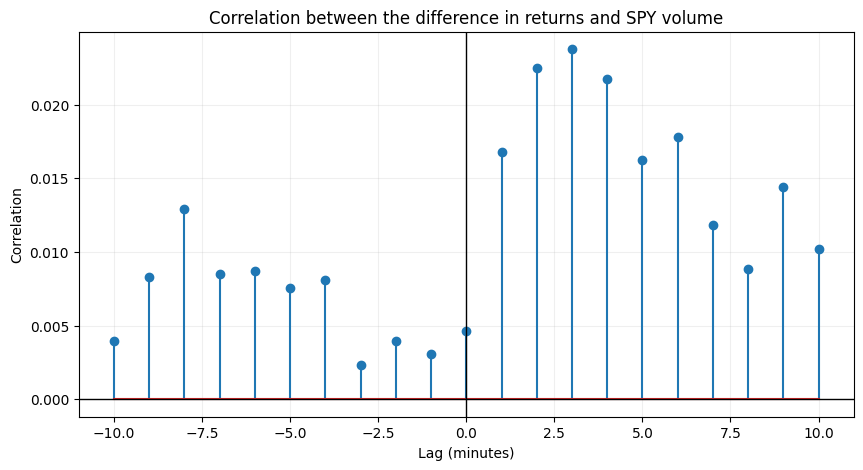

In [161]:
def corr_at_lag(lags, corr, title):
    plt.figure(figsize=(10,5))
    plt.stem(lags, corr)

    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    plt.title(title)
    plt.xlabel("Lag (minutes)")
    plt.ylabel("Correlation")  

    plt.grid(alpha=0.2)
    plt.show()

corr_at_lag(lags, corr_diff_ret_vol_SPY_values, "Correlation between the difference in returns and SPY volume")

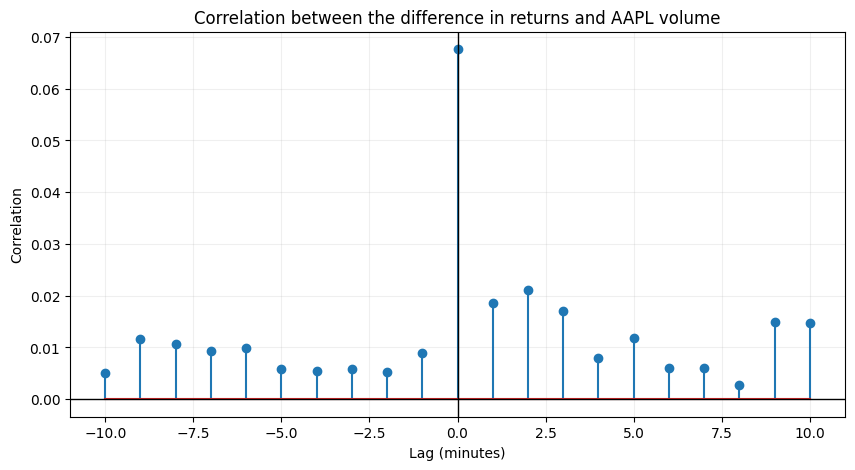

In [162]:
corr_at_lag(lags, corr_diff_ret_vol_AAPL_values, "Correlation between the difference in returns and AAPL volume")

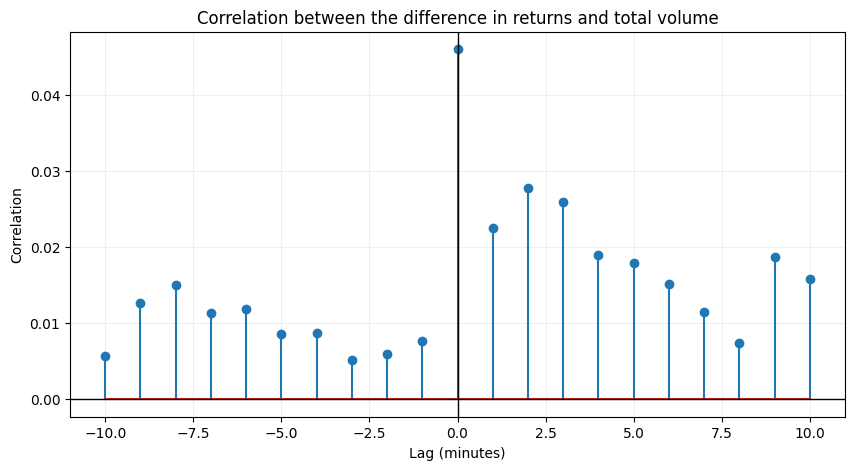

In [163]:
corr_at_lag(lags, corr_diff_ret_vol_tot_values, "Correlation between the difference in returns and total volume")

In [164]:
df_returns_sec = df_returns_sec.with_columns(
    (pl.col("ret_AAPL") - pl.col("ret_SPY")).alias("diff_ret")
)

In [165]:
lags_sec = range(-60, 61)  # -60 à +60
corr_diff_ret_vol_SPY_values_sec = [cross_corr_at_lag(df_returns_sec["diff_ret"], df_returns_sec["volume_SPY"], lag) for lag in lags_sec]
corr_diff_ret_vol_AAPL_values_sec = [cross_corr_at_lag(df_returns_sec["diff_ret"], df_returns_sec["volume_AAPL"], lag) for lag in lags_sec]
corr_diff_ret_vol_tot_values_sec = [cross_corr_at_lag(df_returns_sec["diff_ret"], df_returns_sec["volume_SPY"] + df_returns_sec["volume_AAPL"], lag) for lag in lags_sec]

In [166]:
corr_diff_ret_vol_SPY_table_sec = pd.DataFrame({
    "lag": list(lags_sec),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_SPY_values_sec
})

print(corr_diff_ret_vol_SPY_table_sec)

     lag  corelation between the difference in returns and volatility of SPY
0    -60                                           0.000479                 
1    -59                                          -0.000531                 
2    -58                                           0.000519                 
3    -57                                          -0.000138                 
4    -56                                          -0.001910                 
..   ...                                                ...                 
116   56                                           0.000937                 
117   57                                           0.000002                 
118   58                                           0.001098                 
119   59                                           0.000978                 
120   60                                           0.000633                 

[121 rows x 2 columns]


In [167]:
corr_diff_ret_vol_AAPL_table_sec = pd.DataFrame({
    "lag": list(lags_sec),
    "corelation between the difference in returns and volatility of AAPL": corr_diff_ret_vol_AAPL_values_sec
})

print(corr_diff_ret_vol_AAPL_table_sec)

     lag  corelation between the difference in returns and volatility of AAPL
0    -60                                           0.000034                  
1    -59                                           0.000581                  
2    -58                                          -0.000367                  
3    -57                                          -0.000155                  
4    -56                                          -0.000029                  
..   ...                                                ...                  
116   56                                           0.000311                  
117   57                                          -0.000873                  
118   58                                          -0.000399                  
119   59                                           0.001089                  
120   60                                           0.000882                  

[121 rows x 2 columns]


In [168]:
corr_diff_ret_vol_tot_table_sec = pd.DataFrame({
    "lag": list(lags_sec),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_tot_values_sec
})

print(corr_diff_ret_vol_tot_table_sec)

     lag  corelation between the difference in returns and volatility of SPY
0    -60                                           0.000359                 
1    -59                                           0.000035                 
2    -58                                           0.000106                 
3    -57                                          -0.000205                 
4    -56                                          -0.001356                 
..   ...                                                ...                 
116   56                                           0.000873                 
117   57                                          -0.000609                 
118   58                                           0.000489                 
119   59                                           0.001446                 
120   60                                           0.001060                 

[121 rows x 2 columns]


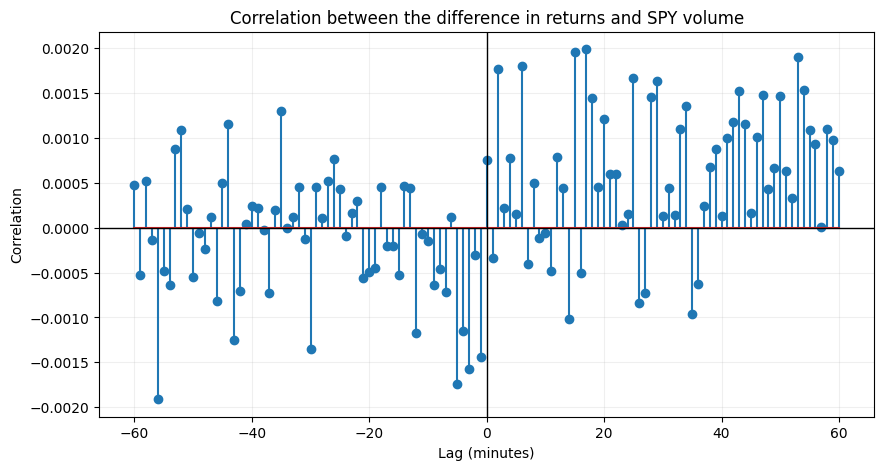

In [169]:
corr_at_lag(lags_sec, corr_diff_ret_vol_SPY_values_sec, "Correlation between the difference in returns and SPY volume")

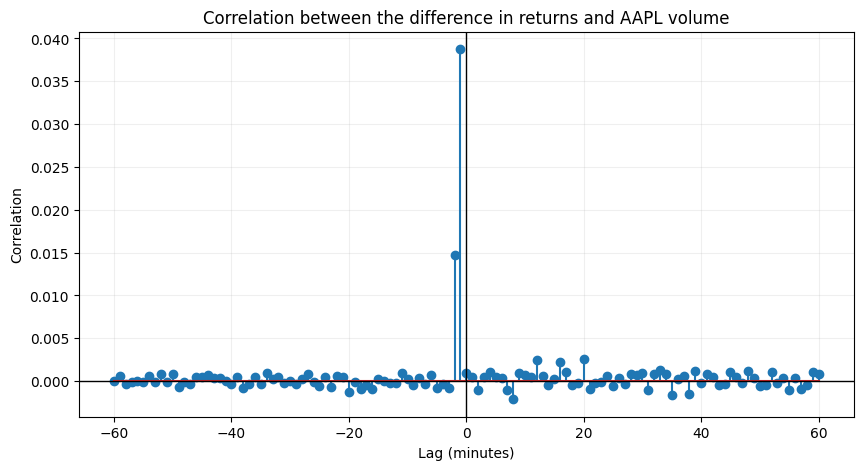

In [170]:
corr_at_lag(lags_sec, corr_diff_ret_vol_AAPL_values_sec, "Correlation between the difference in returns and AAPL volume")

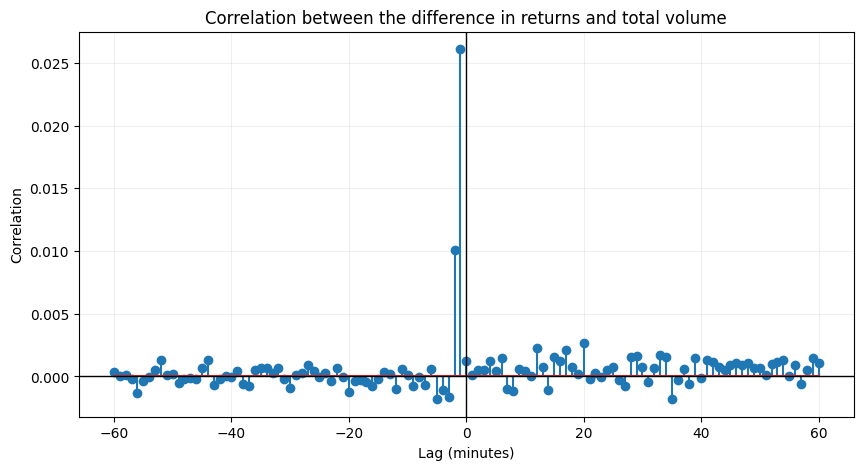

In [171]:
corr_at_lag(lags_sec, corr_diff_ret_vol_tot_values_sec, "Correlation between the difference in returns and total volume")

In [172]:
df_returns_sec = df_returns_sec.with_columns(
    pl.col("diff_ret")
    .rolling_std(window_size=300, min_samples=60)
    .alias("spread_std_5min")
)

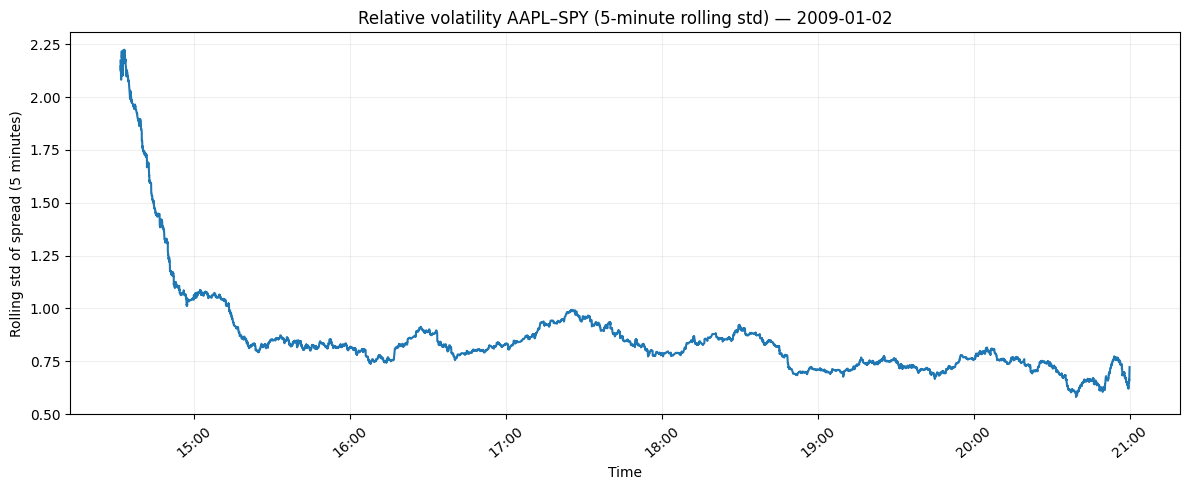

In [173]:
day = df_returns_sec["datetime"][0].date()
df_day = df_returns_sec.filter(pl.col("datetime").dt.date() == day)

plt.figure(figsize=(12,5))
plt.plot(df_day["datetime"], df_day["spread_std_5min"])
plt.xlabel("Time")
plt.ylabel("Rolling std of spread (5 minutes)")
plt.title(f"Relative volatility AAPL–SPY (5-minute rolling std) — {day}")
plt.grid(True, alpha=0.2)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

In [ ]:
df_AAPL_BBO = (pl.scan_parquet("../data/AAPL.OQ.BBO/AAPL.OQ/*.parquet").collect())
print(df_AAPL_BBO.head())

shape: (90_141_426, 5)
┌──────────────┬───────────┬────────────┬───────────┬────────────┐
│ xltime       ┆ bid-price ┆ bid-volume ┆ ask-price ┆ ask-volume │
│ ---          ┆ ---       ┆ ---        ┆ ---       ┆ ---        │
│ f64          ┆ f64       ┆ i32        ┆ f64       ┆ i32        │
╞══════════════╪═══════════╪════════════╪═══════════╪════════════╡
│ 39815.500004 ┆ 0.0       ┆ 0          ┆ 200.0     ┆ 2          │
│ 39815.500848 ┆ 85.2      ┆ 1          ┆ 200.0     ┆ 2          │
│ 39815.50245  ┆ 85.2      ┆ 1          ┆ 86.48     ┆ 1          │
│ 39815.502679 ┆ 80.0      ┆ 1          ┆ 86.48     ┆ 1          │
│ 39815.502703 ┆ 85.35     ┆ 1          ┆ 86.48     ┆ 1          │
│ 39815.50318  ┆ 85.35     ┆ 2          ┆ 86.48     ┆ 1          │
│ 39815.508478 ┆ 85.5      ┆ 3          ┆ 86.48     ┆ 1          │
│ 39815.508537 ┆ 85.35     ┆ 2          ┆ 86.48     ┆ 1          │
│ 39815.508537 ┆ 85.5      ┆ 3          ┆ 86.48     ┆ 1          │
│ 39815.526772 ┆ 85.95     ┆ 1         

In [175]:
origin = dt.datetime(1899, 12, 30)

df_AAPL_BBO = (df_AAPL_BBO.drop_nulls(subset=["xltime", "bid-price", "bid-volume", "ask-price", "ask-volume"]).rename({"xltime": "excel_time",}).with_columns(pl.col("excel_time").map_elements(lambda x: origin + dt.timedelta(days=float(x))).alias("datetime")).drop("excel_time"))

df_AAPL_BBO = df_AAPL_BBO.with_columns(pl.col("datetime").dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York") )

df_AAPL_BBO = (df_AAPL_BBO.filter(pl.col("datetime").dt.time().is_between(pl.time(9, 30), pl.time(16, 0)) ).sort("datetime").select(["datetime", "bid-price", "bid-volume", "ask-price", "ask-volume"]))

print(df_AAPL_BBO.head())
print(df_AAPL_BBO.columns)

shape: (5, 5)
┌────────────────────────────────┬───────────┬────────────┬───────────┬────────────┐
│ datetime                       ┆ bid-price ┆ bid-volume ┆ ask-price ┆ ask-volume │
│ ---                            ┆ ---       ┆ ---        ┆ ---       ┆ ---        │
│ datetime[μs, America/New_York] ┆ f64       ┆ i32        ┆ f64       ┆ i32        │
╞════════════════════════════════╪═══════════╪════════════╪═══════════╪════════════╡
│ 2009-01-02 09:30:00.128 EST    ┆ 85.62     ┆ 2          ┆ 85.9      ┆ 42         │
│ 2009-01-02 09:30:00.322 EST    ┆ 85.62     ┆ 1          ┆ 85.9      ┆ 42         │
│ 2009-01-02 09:30:00.332 EST    ┆ 85.6      ┆ 5          ┆ 85.9      ┆ 42         │
│ 2009-01-02 09:30:00.633 EST    ┆ 85.6      ┆ 2          ┆ 85.9      ┆ 42         │
│ 2009-01-02 09:30:00.698 EST    ┆ 85.56     ┆ 1          ┆ 85.9      ┆ 42         │
└────────────────────────────────┴───────────┴────────────┴───────────┴────────────┘
['datetime', 'bid-price', 'bid-volume', 'ask-price'

In [176]:
df_AAPL_BBO = (df_AAPL_BBO.group_by("datetime").agg([pl.col("bid-price").mean().alias("bid-price"),pl.col("bid-volume").sum().alias("bid-volume"),pl.col("ask-price").mean().alias("ask-price"),pl.col("ask-volume").sum().alias("ask-volume"),]).sort("datetime"))

In [ ]:
df_SPY_BBO = (pl.scan_parquet("../data/SPY.P.BBO/SPY.P/*.parquet").collect())
print(df_SPY_BBO.head())

shape: (110_252_674, 5)
┌──────────────┬───────────┬────────────┬───────────┬────────────┐
│ xltime       ┆ bid-price ┆ bid-volume ┆ ask-price ┆ ask-volume │
│ ---          ┆ ---       ┆ ---        ┆ ---       ┆ ---        │
│ f64          ┆ f64       ┆ i32        ┆ f64       ┆ i32        │
╞══════════════╪═══════════╪════════════╪═══════════╪════════════╡
│ 39675.337041 ┆ 130.12    ┆ 20         ┆ 130.18    ┆ 20         │
│ 39675.337094 ┆ 130.13    ┆ 20         ┆ 130.18    ┆ 20         │
│ 39675.337358 ┆ 130.14    ┆ 20         ┆ 130.18    ┆ 20         │
│ 39675.337388 ┆ 130.13    ┆ 20         ┆ 130.18    ┆ 20         │
│ 39675.337388 ┆ 130.13    ┆ 20         ┆ 130.17    ┆ 20         │
│ 39675.337388 ┆ 130.12    ┆ 20         ┆ 130.17    ┆ 20         │
│ 39675.337391 ┆ 130.11    ┆ 20         ┆ 130.17    ┆ 20         │
│ 39675.337393 ┆ 130.11    ┆ 20         ┆ 130.16    ┆ 20         │
│ 39675.337473 ┆ 130.11    ┆ 20         ┆ 130.17    ┆ 20         │
│ 39675.337496 ┆ 130.11    ┆ 20       

In [178]:
origin = dt.datetime(1899, 12, 30)

df_SPY_BBO = (df_SPY_BBO.drop_nulls(subset=["xltime", "bid-price", "bid-volume", "ask-price", "ask-volume"]).rename({"xltime": "excel_time",}).with_columns(pl.col("excel_time").map_elements(lambda x: origin + dt.timedelta(days=float(x))).alias("datetime")).drop("excel_time"))

df_SPY_BBO = df_SPY_BBO.with_columns(pl.col("datetime").dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York") )

df_SPY_BBO = (df_SPY_BBO.filter(pl.col("datetime").dt.time().is_between(pl.time(9, 30), pl.time(16, 0)) ).sort("datetime").select(["datetime", "bid-price", "bid-volume", "ask-price", "ask-volume"]))

print(df_SPY_BBO.head())
print(df_SPY_BBO.columns)

shape: (5, 5)
┌────────────────────────────────┬───────────┬────────────┬───────────┬────────────┐
│ datetime                       ┆ bid-price ┆ bid-volume ┆ ask-price ┆ ask-volume │
│ ---                            ┆ ---       ┆ ---        ┆ ---       ┆ ---        │
│ datetime[μs, America/New_York] ┆ f64       ┆ i32        ┆ f64       ┆ i32        │
╞════════════════════════════════╪═══════════╪════════════╪═══════════╪════════════╡
│ 2008-08-15 09:30:00.002 EDT    ┆ 129.9     ┆ 84         ┆ 129.92    ┆ 66         │
│ 2008-08-15 09:30:00.002 EDT    ┆ 129.9     ┆ 84         ┆ 129.92    ┆ 166        │
│ 2008-08-15 09:30:00.012 EDT    ┆ 129.9     ┆ 67         ┆ 129.91    ┆ 34         │
│ 2008-08-15 09:30:00.012 EDT    ┆ 129.9     ┆ 69         ┆ 129.91    ┆ 34         │
│ 2008-08-15 09:30:00.098 EDT    ┆ 129.9     ┆ 61         ┆ 129.91    ┆ 34         │
└────────────────────────────────┴───────────┴────────────┴───────────┴────────────┘
['datetime', 'bid-price', 'bid-volume', 'ask-price'

In [179]:
df_SPY_BBO = (df_SPY_BBO.group_by("datetime").agg([pl.col("bid-price").mean().alias("bid-price"),pl.col("bid-volume").sum().alias("bid-volume"),pl.col("ask-price").mean().alias("ask-price"),pl.col("ask-volume").sum().alias("ask-volume"),]).sort("datetime"))

In [180]:
def bucket_1min_bbo(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by_dynamic(
            "datetime",
            every="1m",
            period="1m",
            closed="left",
            label="left",
        )
        .agg([
            pl.col("bid-price").mean().alias("bid-price"),
            pl.col("bid-volume").sum().alias("bid-volume"),
            pl.col("ask-price").mean().alias("ask-price"),
            pl.col("ask-volume").sum().alias("ask-volume"),
        ])
        .sort("datetime")
    )

In [181]:
df_SPY_BBO_min = bucket_1min_bbo(df_SPY_BBO)
df_AAPL_BBO_min = bucket_1min_bbo(df_AAPL_BBO)

In [182]:
df_AAPL_BBO_min = df_AAPL_BBO_min.rename({"datetime": "datetime","bid-price": "bid-price_AAPL","bid-volume": "bid-volume_AAPL","ask-price": "ask-price_AAPL","ask-volume": "ask-volume_AAPL",})

In [183]:
df_SPY_BBO_min = df_SPY_BBO_min.rename({"datetime": "datetime","bid-price": "bid-price_SPY","bid-volume": "bid-volume_SPY","ask-price": "ask-price_SPY","ask-volume": "ask-volume_SPY",})

In [184]:
df_BBO_min = (
    df_AAPL_BBO_min
    .join(df_SPY_BBO_min, on="datetime", how="inner")
    .select([
        "datetime",
        "bid-price_AAPL", 
        "bid-volume_AAPL",
        "ask-price_AAPL",
        "ask-volume_AAPL",
        "bid-price_SPY",
        "bid-volume_SPY",
        "ask-price_SPY",
        "ask-volume_SPY",
    ])       
)

In [185]:
df_BBO_min = df_BBO_min.with_columns([
    (pl.col("ask-price_AAPL") - pl.col("bid-price_AAPL")).alias("spread_AAPL"),
    (pl.col("ask-price_SPY")  - pl.col("bid-price_SPY")).alias("spread_SPY"),
])

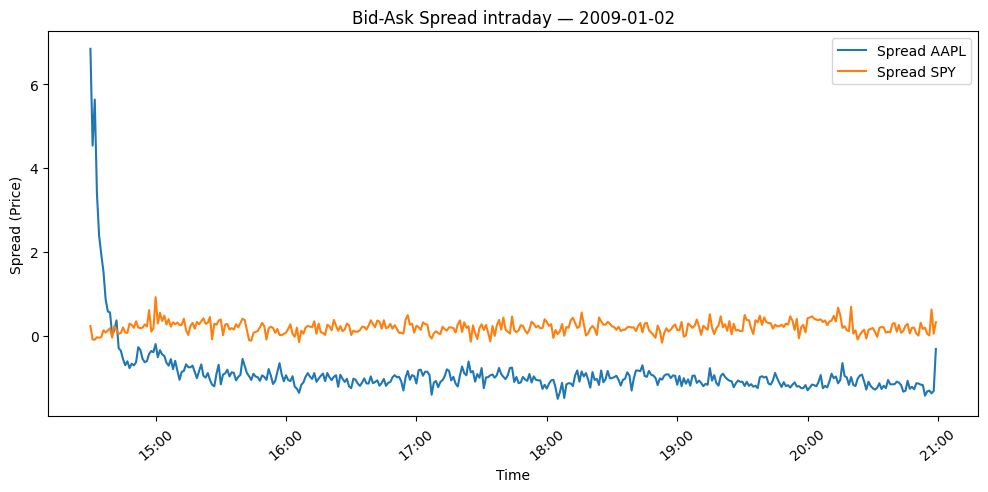

In [189]:
day = df_BBO_min["datetime"][0].date()
df_day_bbo = df_BBO_min.filter(pl.col("datetime").dt.date() == day)
plt.figure(figsize=(12,5))
plt.plot(df_day_bbo["datetime"], df_day_bbo["spread_AAPL"], label="Spread AAPL")
plt.plot(df_day_bbo["datetime"], df_day_bbo["spread_SPY"], label="Spread SPY")
plt.title(f"Bid-Ask Spread intraday — {day}")
plt.xlabel("Time")
plt.ylabel("Spread (Price)")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)
plt.show()

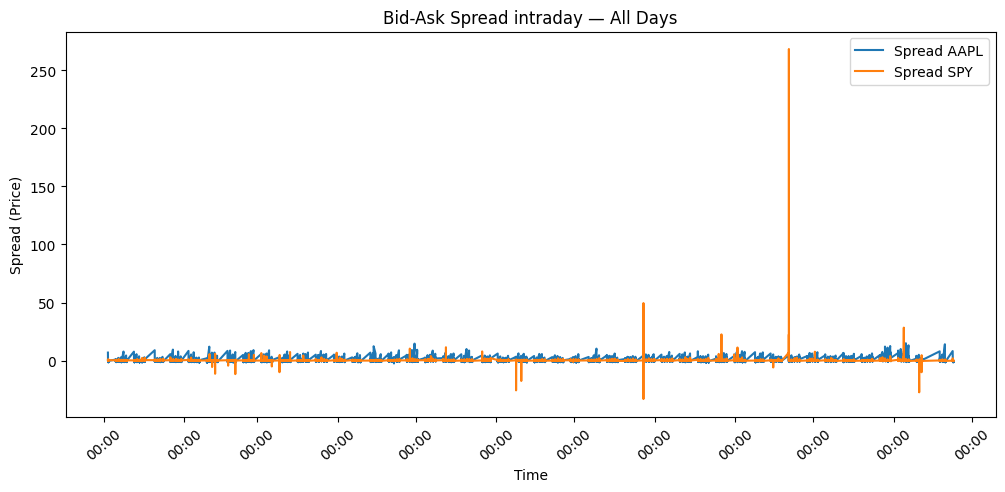

In [190]:
plt.figure(figsize=(12,5))
plt.plot(df_BBO_min["datetime"], df_BBO_min["spread_AAPL"], label="Spread AAPL")
plt.plot(df_BBO_min["datetime"], df_BBO_min["spread_SPY"], label="Spread SPY")
plt.title(f"Bid-Ask Spread intraday — All Days")
plt.xlabel("Time")
plt.ylabel("Spread (Price)")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)
plt.show()

In [187]:
spread_AAPL_mean = df_BBO_min["spread_AAPL"].mean()
spread_AAPL_std = df_BBO_min["spread_AAPL"].std()
spread_SPY_mean = df_BBO_min["spread_SPY"].mean()
spread_SPY_std = df_BBO_min["spread_SPY"].std()
print(f"AAPL Spread Mean: {spread_AAPL_mean}, Std: {spread_AAPL_std}")
print(f"SPY Spread Mean: {spread_SPY_mean}, Std: {spread_SPY_std}")
print("Let's normalize and center the spreads.")

df_BBO_min = df_BBO_min.with_columns([
    ((pl.col("spread_AAPL") - spread_AAPL_mean) / spread_AAPL_std).alias("spread_AAPL"),
    ((pl.col("spread_SPY") - spread_SPY_mean) / spread_SPY_std).alias("spread_SPY"),
])
df_BBO_min = df_BBO_min.select(["datetime", "spread_AAPL", "spread_SPY"])

AAPL Spread Mean: 0.03417059415745302, Std: 0.013493620080552746
SPY Spread Mean: 0.013433609933487809, Std: 0.007349322953358946
Let's normalize and center the spreads.


In [188]:
print(df_BBO_min.head())

shape: (5, 3)
┌────────────────────────────────┬─────────────┬────────────┐
│ datetime                       ┆ spread_AAPL ┆ spread_SPY │
│ ---                            ┆ ---         ┆ ---        │
│ datetime[μs, America/New_York] ┆ f64         ┆ f64        │
╞════════════════════════════════╪═════════════╪════════════╡
│ 2009-01-02 09:30:00 EST        ┆ 6.843399    ┆ 0.229686   │
│ 2009-01-02 09:31:00 EST        ┆ 4.535191    ┆ -0.093006  │
│ 2009-01-02 09:32:00 EST        ┆ 5.633114    ┆ -0.095372  │
│ 2009-01-02 09:33:00 EST        ┆ 3.385224    ┆ -0.038616  │
│ 2009-01-02 09:34:00 EST        ┆ 2.383678    ┆ -0.049247  │
└────────────────────────────────┴─────────────┴────────────┘
